## 1. Introduction


<!--  -->

### 1.1 Contexte et Objectifs



Cette étude analyse les entretiens réalisés avec 1,250 professionnels sur leur utilisation de l'IA au travail, en utilisant le dataset **Anthropic Interviewer**.


### 1.2 Positionnement par rapport à l'étude Anthropic



| Dimension analysée              | Fait dans l'interview Anthropic | Ajouté dans ce projet   |
| ------------------------------- | ------------------------------- | ----------------------- |
| Sentiment global                | ✅ Oui                           | ❌ Non (non redondant)   |
| Augmentation vs Automation      | ✅ Oui                           | ❌ Non                   |
| Thèmes globaux                  | ✅ Oui                           | ❌ Non                   |
| Comparaison par groupe          | ✅ Oui                           | ❌ Non                   |
| Clustering des profils          | ⚠️ Partiel                      | ✅ Approfondi (conservé) |
| Évolution dans l'entretien      | ❌ Non                           | ✅ Oui                   |
| Identité professionnelle        | ❌ Non                           | ✅ Oui                   |
| Stratégies d'adaptation         | ❌ Non                           | ✅ Oui                   |
| Dissonance discours / pratiques | ❌ Non                           | ✅ Oui                   |
| Stigmatisation sociale          | ❌ Non                           | ✅ Oui                   |
| Inégalités professionnelles     | ❌ Non                           | ✅ Oui                   |

In [1]:
import pandas as pd

splits = {'workforce': 'interview_transcripts/workforce_transcripts.csv', 'creatives': 'interview_transcripts/creatives_transcripts.csv', 'scientists': 'interview_transcripts/scientists_transcripts.csv'}
df = pd.read_csv("hf://datasets/Anthropic/AnthropicInterviewer/" + splits["workforce"])

In [2]:
# === IMPORTS DES MODULES D'ANALYSE AVANCÉE ===
# Tous les imports nécessaires pour les analyses avancées (sections 6.1 à 6.6)

# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Imports des modules d'analyse avancée
from llm_config import call_llm_json, USE_LLM, FINAL_ANNOTATION_PROMPT
from semantic_anchors import setup_semantic_anchors, calculate_anchor_embeddings, add_similarity_columns
from analysis_evolution import analyze_discourse_evolution, visualize_evolution
from analysis_identity import analyze_identity, visualize_identity_fragility
from analysis_adaptation import analyze_adaptation_strategies, visualize_adaptation_strategies
from analysis_dissonance import analyze_dissonance, visualize_dissonance
from analysis_stigma import analyze_stigma, visualize_stigma
from analysis_inequality import analyze_inequality, visualize_inequality
from analysis_profiles import merge_profiles, visualize_profiles_summary

print("✓ Tous les modules d'analyse avancée importés")
print(f"  - Mode LLM: {'Activé' if USE_LLM else 'Désactivé (embeddings uniquement)'}")


⚠ python-dotenv non disponible, utilisation des variables d'environnement système uniquement
✓ GEMINI_API_KEY détectée
   Provider: gemini

Mode d'exécution: LLM + Embeddings
✓ Nouveau cache créé
✓ Fonction call_llm_json configurée
  - Cache: 0 entrées
  - Batch size: 8
  - Provider: gemini
✓ Tous les modules d'analyse avancée importés
  - Mode LLM: Activé


## 2. Exploration des données

In [3]:
df.head()

,transcript_id,text
0,work_0000,Assistant: Hi there! I'm Claude from Anthropic...
1,work_0001,Assistant: Hi there! I'm Claude from Anthropic...
2,work_0002,Assistant: Hi there! I'm Claude from Anthropic...
3,work_0003,Assistant: Hi there! I'm Claude from Anthropic...
4,work_0004,Assistant: Hi there! I'm Claude from Anthropic...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transcript_id  1000 non-null   object
 1   text           1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [5]:
# Informations générales sur le dataset
print("=== INFORMATIONS GÉNÉRALES ===")
print(f"Nombre de lignes: {len(df)}")
print(f"Nombre de colonnes: {len(df.columns)}")
print(f"\nColonnes du dataset:")
print(df.columns.tolist())
print(f"\nTypes de données:")
print(df.dtypes)
print(f"\nMémoire utilisée: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


=== INFORMATIONS GÉNÉRALES ===
Nombre de lignes: 1000
Nombre de colonnes: 2

Colonnes du dataset:
['transcript_id', 'text']

Types de données:
transcript_id    object
text             object
dtype: object

Mémoire utilisée: 17.85 MB


In [6]:
# Statistiques descriptives pour les colonnes numériques
print("=== STATISTIQUES DESCRIPTIVES (colonnes numériques) ===")
df.describe()

=== STATISTIQUES DESCRIPTIVES (colonnes numériques) ===


,transcript_id,text
count,1000,1000
unique,1000,1000
top,work_0999,Assistant: Hi there! I'm Claude from Anthropic...
freq,1,1


In [7]:
# Analyse des colonnes catégorielles/textuelles
print("=== ANALYSE DES COLONNES CATÉGORIELLES ===")
for col in df.columns:
    if df[col].dtype == 'object':
        unique_count = df[col].nunique()
        print(f"\n{col}:")
        print(f"  - Nombre de valeurs uniques: {unique_count}")
        if unique_count < 20:
            print(f"  - Valeurs uniques: {df[col].unique()}")
        else:
            print(f"  - Premières valeurs: {df[col].value_counts().head(10).to_dict()}")

=== ANALYSE DES COLONNES CATÉGORIELLES ===

transcript_id:
  - Nombre de valeurs uniques: 1000
  - Premières valeurs: {'work_0999': 1, 'work_0000': 1, 'work_0001': 1, 'work_0002': 1, 'work_0003': 1, 'work_0004': 1, 'work_0005': 1, 'work_0006': 1, 'work_0983': 1, 'work_0982': 1}

text:
  - Nombre de valeurs uniques: 1000
  - Premières valeurs: {"Assistant: Hi there! I'm Claude from Anthropic's research team. Thank you so much for taking the time to speak with me today. \n\nWe're conducting interviews to better understand how people are incorporating AI tools like Claude into their work routines. Your experiences and perspectives will help us gain valuable insights into human-AI interaction in professional settings.\n\nDuring our conversation, I'll ask questions about how you use AI in your work, your preferences, and your thoughts about working with these tools. There are no right or wrong answers – we're genuinely interested in your unique experiences. This should take about 10 minutes

In [8]:
# Analyse de la longueur des textes (si colonnes textuelles existent)
import numpy as np

print("=== ANALYSE DES LONGUEURS DE TEXTE ===")
for col in df.columns:
    if df[col].dtype == 'object':
        # Calculer la longueur des textes
        text_lengths = df[col].astype(str).str.len()
        print(f"\n{col}:")
        print(f"  - Longueur moyenne: {text_lengths.mean():.2f} caractères")
        print(f"  - Longueur médiane: {text_lengths.median():.2f} caractères")
        print(f"  - Longueur min: {text_lengths.min()} caractères")
        print(f"  - Longueur max: {text_lengths.max()} caractères")
        print(f"  - Écart-type: {text_lengths.std():.2f} caractères")

=== ANALYSE DES LONGUEURS DE TEXTE ===

transcript_id:
  - Longueur moyenne: 9.00 caractères
  - Longueur médiane: 9.00 caractères
  - Longueur min: 9 caractères
  - Longueur max: 9 caractères
  - Écart-type: 0.00 caractères

text:
  - Longueur moyenne: 9230.87 caractères
  - Longueur médiane: 8809.50 caractères
  - Longueur min: 4837 caractères
  - Longueur max: 26826 caractères
  - Écart-type: 2443.34 caractères


## 3. Préprocessing - Segmentation des conversations

In [9]:
import pandas as pd
import re

def split_conversation(text):
    # Découpage du texte selon les locuteurs
    parts = re.split(r'(Assistant:|AI:|User:)', text)

    # Nettoyage initial : on enlève les éléments vides
    cleaned_parts = [p.strip() for p in parts if p.strip()]

    turns = {}
    ai_count = 1
    user_count = 1

    for i in range(0, len(cleaned_parts) - 1, 2):
        speaker = cleaned_parts[i]
        content = cleaned_parts[i+1]

        # NETTOYAGE :
        # 1. Remplacer les sauts de ligne (\n, \r) par un espace
        # 2. Supprimer les doubles espaces créés par le remplacement
        # 3. Strip final pour les bords
        clean_content = re.sub(r'[\n\r]+', ' ', content)
        clean_content = re.sub(r'\s+', ' ', clean_content).strip()

        if "Assistant" in speaker or "AI" in speaker:
            turns[f'AI_Turn_{ai_count}'] = clean_content
            ai_count += 1
        elif "User" in speaker:
            turns[f'User_Turn_{user_count}'] = clean_content
            user_count += 1

    return pd.Series(turns)

# Application sur le DataFrame
df_turns = df['text'].apply(split_conversation)
df_final = pd.concat([df['transcript_id'], df_turns], axis=1)

# Vérification rapide du texte propre
print(df_final.loc[0, 'AI_Turn_2'])

Great! Let's dive in. Could you tell me about how AI fits into your typical workday? What kinds of tasks do you use it for?


In [10]:
df_final[['transcript_id', 'AI_Turn_1', 'User_Turn_1', 'AI_Turn_2']].head()

,transcript_id,AI_Turn_1,User_Turn_1,AI_Turn_2
0,work_0000,Hi there! I'm Claude from Anthropic's research...,"No, I don't have any questions. Let's do it!",Great! Let's dive in. Could you tell me about ...
1,work_0001,Hi there! I'm Claude from Anthropic's research...,That sounds good.,Great! Let's dive in then. Could you tell me a...
2,work_0002,Hi there! I'm Claude from Anthropic's research...,"No questions, we can begin",Great! Let's dive in then. Could you tell me a...
3,work_0003,Hi there! I'm Claude from Anthropic's research...,Soinds good. Let's proceed.,Great! Let's dive in. Could you tell me about ...
4,work_0004,Hi there! I'm Claude from Anthropic's research...,"Sounds good to me, let's begin.",Great! Let's dive right in. Could you tell me ...


In [11]:
# Remplacer les \n par un espace et enlever les espaces en trop
df_final = df_final.applymap(lambda x: x.replace('\n', ' ').strip() if isinstance(x, str) else x)

# Afficher le résultat pour vérifier
df_final.head()

C:\Users\Khyro\AppData\Local\Temp\ipykernel_25300\871383331.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_final = df_final.applymap(lambda x: x.replace('\n', ' ').strip() if isinstance(x, str) else x)


,transcript_id,AI_Turn_1,User_Turn_1,AI_Turn_2,User_Turn_2,AI_Turn_3,User_Turn_3,AI_Turn_4,User_Turn_4,AI_Turn_5,...,User_Turn_21,User_Turn_22,User_Turn_23,User_Turn_24,User_Turn_25,AI_Turn_26,User_Turn_26,AI_Turn_27,User_Turn_27,AI_Turn_28
0,work_0000,Hi there! I'm Claude from Anthropic's research...,"No, I don't have any questions. Let's do it!",Great! Let's dive in. Could you tell me about ...,I pretty rarely use AI in my typical workday. ...,Tell me more about those situations where you ...,I will open the AI model and provide it with a...,What happens after the AI gives you those stra...,"I always modify them. They're never ""perfect""....",That's really interesting - you're essentially...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,work_0001,Hi there! I'm Claude from Anthropic's research...,That sounds good.,Great! Let's dive in then. Could you tell me a...,I use AI sparingly at my job. I only use it to...,Tell me more about that. What made you decide ...,I use Grammarly primarily. I'd been asked to u...,That's interesting - you mentioned you don't a...,Sure. I almost always use its spelling suggest...,That makes a lot of sense - wanting to maintai...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,work_0002,Hi there! I'm Claude from Anthropic's research...,"No questions, we can begin",Great! Let's dive in then. Could you tell me a...,I've used it primarily in the creation of spre...,That's a really practical use case. When you s...,"So using my specific use case example, I would...",Tell me more about how that process unfolds fr...,"From my past experience, it usually takes a co...",That makes a lot of sense - there's this gap b...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,work_0003,Hi there! I'm Claude from Anthropic's research...,Soinds good. Let's proceed.,Great! Let's dive in. Could you tell me about ...,I'm in real estate so I use Ai for a variety o...,That's interesting - it sounds like AI touches...,For property descriptions I will typically ent...,That's a really practical approach. You mentio...,"I definitely include the basics of room count,...",That makes a lot of sense - you're providing t...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,work_0004,Hi there! I'm Claude from Anthropic's research...,"Sounds good to me, let's begin.",Great! Let's dive right in. Could you tell me ...,I'm a data analyst at SUEZ and I use AI for a ...,That's really helpful - it sounds like AI is t...,"Yes , I often tell it to write the entire code...",That's interesting - so you've developed diffe...,I'd prefer if AI could handle it independently...,That's a great observation about AI seeming to...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Filtre structurel - Garder uniquement les réponses du participant

In [12]:
# 1. Lister toutes les colonnes actuelles
all_columns = df_final.columns

# 2. Boucle for pour identifier les colonnes à supprimer
cols_to_drop = []
for col in all_columns:
    if "User" not in col:
        cols_to_drop.append(col)

# 3. Supprimer les colonnes (on garde uniquement celles contenant "User")
df_user_only = df_final.drop(columns=cols_to_drop)

# 4. Affichage complet des 2 premières lignes
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

display(df_user_only.head(2))

,User_Turn_1,User_Turn_2,User_Turn_3,User_Turn_4,User_Turn_5,User_Turn_6,User_Turn_7,User_Turn_8,User_Turn_9,User_Turn_10,User_Turn_11,User_Turn_12,User_Turn_13,User_Turn_14,User_Turn_15,User_Turn_16,User_Turn_17,User_Turn_18,User_Turn_19,User_Turn_20,User_Turn_21,User_Turn_22,User_Turn_23,User_Turn_24,User_Turn_25,User_Turn_26,User_Turn_27
0,"No, I don't have any questions. Let's do it!",I pretty rarely use AI in my typical workday. I tend to only use it when I need help coming up with new sales strategies or different ways to improve interactions with customers.,I will open the AI model and provide it with a scenario that I may run into at work and ask it to come up with a unique strategy to increase my chances of making a sale.,"I always modify them. They're never ""perfect"". Sometimes they're repetitive or not relevant for my work. However, I still use the overall strategy.",I do not believe there are any tasks that AI could help with that I prefer to do myself in my line of work.,"I turn to AI when I'm stuck. For example, if there's a new product I'm selling and I don't know how to pitch it to someone, I will turn to AI for help.",I tend to give it all the context up front. I do not typically go back and forth with the AI.,"My colleagues have influenced the way I use AI because I tend to use it more often when I need to ""compete"" with them. If my sales for the month are low compared to them, I tend to turn to AI for help.",One time I used AI to develop a strategy for selling a product I wasn't familiar with and it worked extremely well. I was very satisfied because I made the most sales that month out of my whole team.,I gave a lot of details in this specific scenario. I provided as much details as possible and I noticed it really made a difference. I also included information about myself and my personality to help the AI cater the strategy to myself as a person.,I've thought about it a bit but I prefer to work with AI and use it to better myself instead of competing.,"I think I will continue to use it the way I have. I hope in the future, the AI will improve and thus improve my performance at work as well.","No, that is all.",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,That sounds good.,I use AI sparingly at my job. I only use it to make sure that my grammar and spelling are correct on the emails I send to clients.,"I use Grammarly primarily. I'd been asked to use it for a task at a part time job at one point and, after trying it out, I found it superior to my computer's normal spell/grammar check. Grammarly catches a lot more issues than my computer does, though I don't always use its suggestions.","Sure. I almost always use its spelling suggestions, but sometimes it gives me tips on sentence flow or how to make my sentences sound more friendly or more formal that don't really sound like the way I'd talk or write, so I ignore them. I want to make sure I don't have grammar errors when writing to my clients, but I also want to preserve my voice as I am the sole owner and operator at my business.","For the most part, I'd prefer to handle anything besides grammar on my own. I'm a home inspector, so there isn't a lot of my business that can be handled by AI. The only other tasks I can think of would be something like scheduling tasks, but that doesn't take up much of my time so I don't feel the need to delegate it. It's possible that AI could help me write my reports, but I need to use very specific language and I already have templates for that.","Sure. It's important that my clients can understand what I'm talking about, but also that I state things in a way that keeps me as safe from litigation as possible. The templates I use are based on what I learned in my inspection classes and also, every state has different requirements for what needs to be reported and how.","At this point, I don't think the home inspection industry is using AI very much, at least I haven't heard about it. I did want to point out

## 5. Clustering des utilisateurs

### 5.1 Préparation et Vectorisation

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1. On crée une colonne qui fusionne toutes les réponses User non-vides
# On utilise df_user_only créé précédemment
df_user_only['combined_user_text'] = df_user_only.apply(
    lambda row: ' '.join([str(val) for val in row if pd.notna(val)]), axis=1
)

# 2. Vectorisation (TF-IDF)
# On ignore les mots qui apparaissent dans moins de 2 entretiens (min_df=2)
tfidf = TfidfVectorizer(stop_words='english', max_features=1000, min_df=2)
X = tfidf.fit_transform(df_user_only['combined_user_text'])

# 3. Clustering K-Means (On commence avec 3 groupes : ex: Positifs, Prudents, Occasionnels)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_user_only['cluster'] = kmeans.fit_predict(X)

C:\Users\Khyro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Khyro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [14]:
df_user_only

User_Turn_1  \
0         No, I don't have any questions. Let's do it!   
1                                    That sounds good.   
2                           No questions, we can begin   
3                          Soinds good. Let's proceed.   
4                      Sounds good to me, let's begin.   
..                                                 ...   
995  That sounds good, and I don't have any questions.   
996              Sounds good to me. Let's get started.   
997                                     Nope, all good   
998                           No I don't, we can begin   
999                   Happy with that. Please proceed.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     User_Turn_2  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             I pretty rarely use AI in my typical workday. I tend to only use it when I need help coming up with new sales strategies or different ways to improve interactions with customers.   
1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             I use AI sparingly at my job. I only use it to make sure that my grammar and spelling are correct on the emails I send to clients.   
2                                                                                                                                                                             I've used it primarily in the creation of spreadsheets. For example, there have been times when I need to track certain information relating to hiring or other data sets I need to share with the employees and I need a spreadsheet to contain certain formulas. I might not always be up on the necessary formulas to get the spreadsheet to organize my data the way I want, or I may have forgotten, if I haven't created that type of spreadsheet in a while or have been using my old templates for a long time, so in tools such

### 5.2 Analyse des mots-clés par cluster

In [15]:
# Fonction pour voir les mots clés de chaque cluster
def get_top_keywords(n_terms):
    terms = tfidf.get_feature_names_out()
    centroids = kmeans.cluster_centers_
    for i in range(n_clusters):
        print(f"\n--- CLUSTER {i} ---")
        top_indices = centroids[i].argsort()[-n_terms:][::-1]
        print([terms[ind] for ind in top_indices])

get_top_keywords(10)


--- CLUSTER 0 ---
['ai', 'students', 'lesson', 'use', 'student', 'teacher', 'teaching', 'like', 'teachers', 'think']

--- CLUSTER 1 ---
['ai', 'use', 'work', 'like', 'think', 'time', 'don', 'help', 'information', 'just']

--- CLUSTER 2 ---
['code', 'ai', 'use', 'coding', 'work', 'like', 'time', 'think', 'tasks', 'problem']


### 5.3 Visualisation des groupes (PCA)

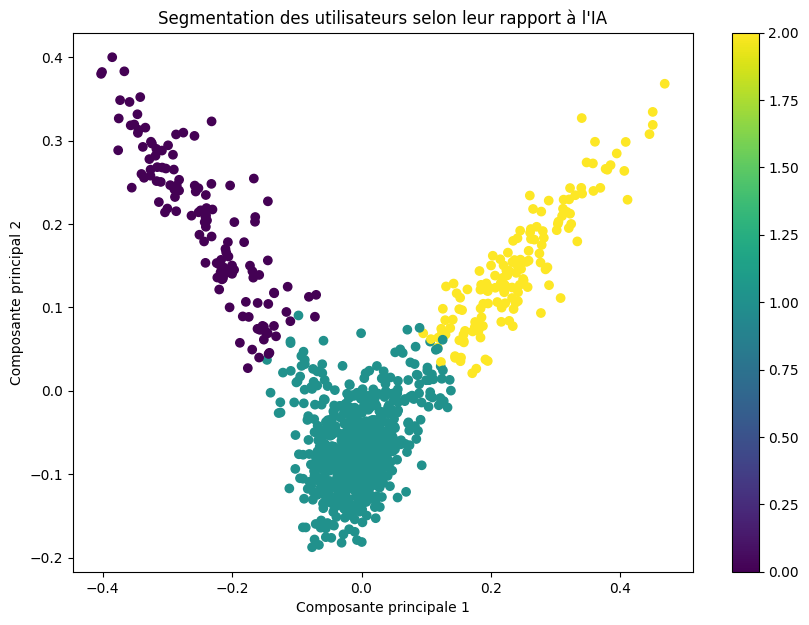

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=df_user_only['cluster'], cmap='viridis')
plt.colorbar(scatter)
plt.title("Segmentation des utilisateurs selon leur rapport à l'IA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principal 2")
plt.show()

Interprétation possible des résultats :
Cluster 0 : Utilisateurs focalisés sur la performance/compétition (mots : sales, strategy, compete).

Cluster 1 : Utilisateurs occasionnels ou pragmatiques (mots : stuck, help, simple).

Cluster 2 : Utilisateurs créatifs ou techniques (mots : writing, code, brainstorming).

### 5.4 Analyse thématique par groupe (embeddings sémantiques)

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

✓ sentence-transformers disponible → Analyse des thèmes par cluster
Chargement du modèle sémantique...
Calcul des embeddings pour 11983 répliques...


Batches:   0%|          | 0/375 [00:00<?, ?it/s]


=== ANALYSE DES THÈMES PAR CLUSTER ===

📊 CLUSTER 0 (1549 répliques):
  Créativité                0.4706 ██████████████████
  Technique                 0.4091 ████████████████
  Performance               0.3156 ████████████
  Tâches opérationnelles    0.3094 ████████████
  Communication             0.3034 ████████████
  Collaboration             0.2899 ███████████
  Stratégie                 0.2591 ██████████
  → Thème dominant : Créativité

📊 CLUSTER 1 (8617 répliques):
  Créativité                0.4540 ██████████████████
  Technique                 0.4247 ████████████████
  Performance               0.3622 ██████████████
  Tâches opérationnelles    0.3359 █████████████
  Communication             0.3290 █████████████
  Stratégie                 0.3186 ████████████
  Collaboration             0.3168 ████████████
  → Thème dominant : Créativité

📊 CLUSTER 2 (1817 répliques):
  Technique                 0.4980 ███████████████████
  Créativité                0.4376 █████████████████
  

C:\Users\Khyro\AppData\Local\Temp\ipykernel_25300\2569819311.py:134: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Khyro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


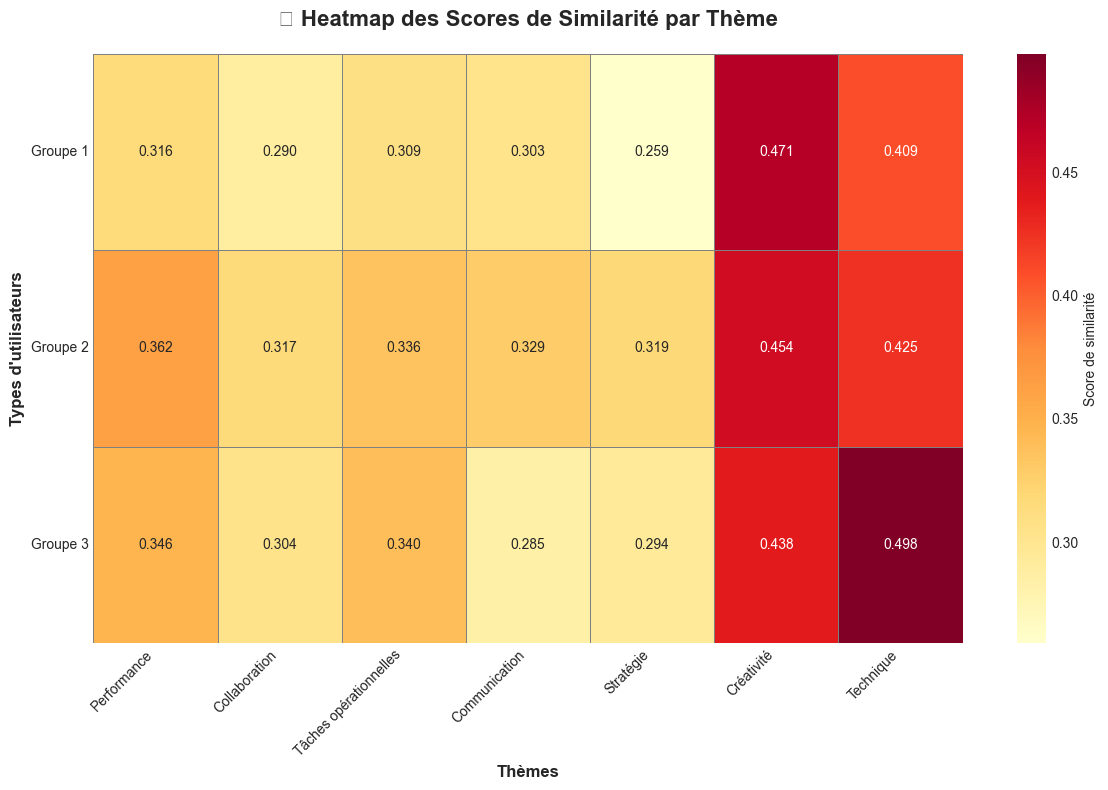

C:\Users\Khyro\AppData\Local\Temp\ipykernel_25300\2569819311.py:155: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Khyro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


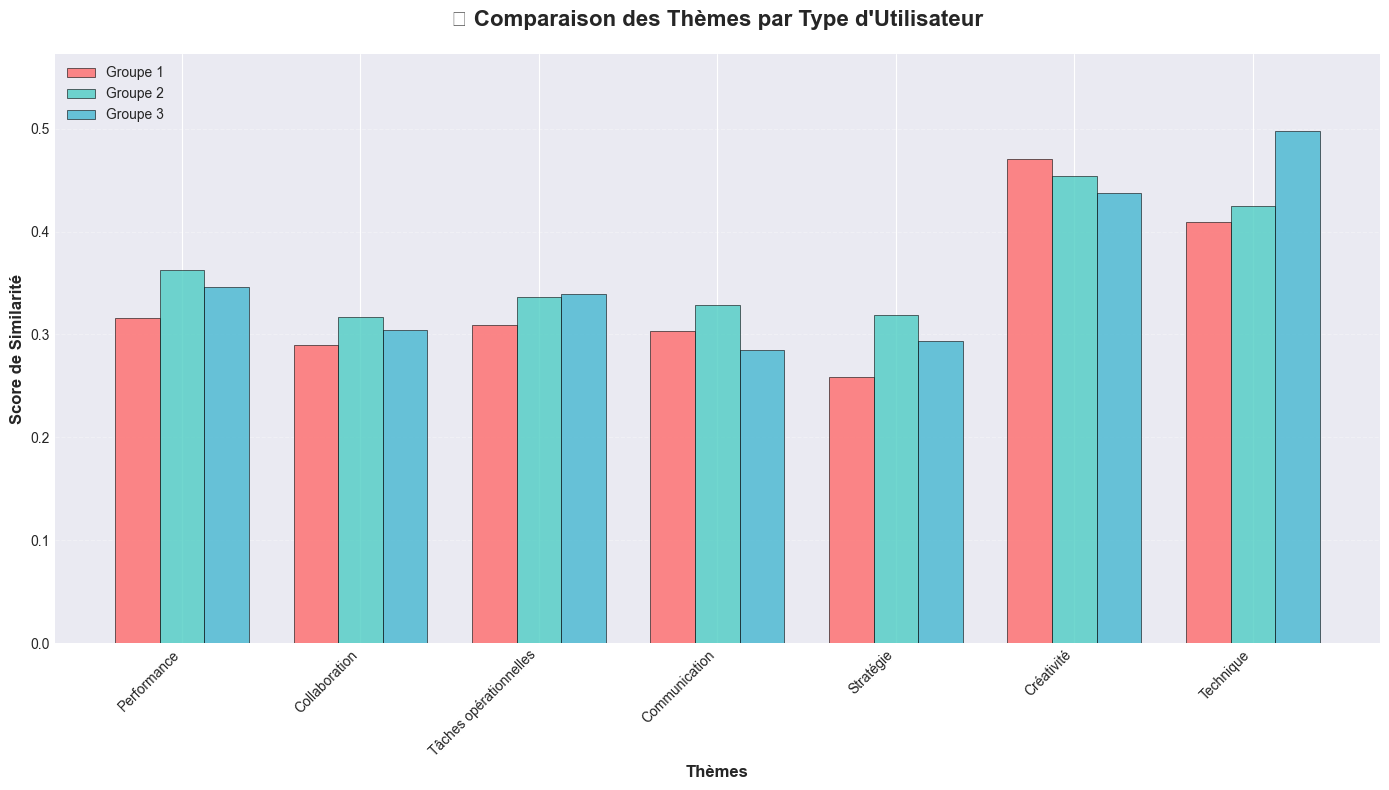

C:\Users\Khyro\AppData\Local\Temp\ipykernel_25300\2569819311.py:176: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Khyro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


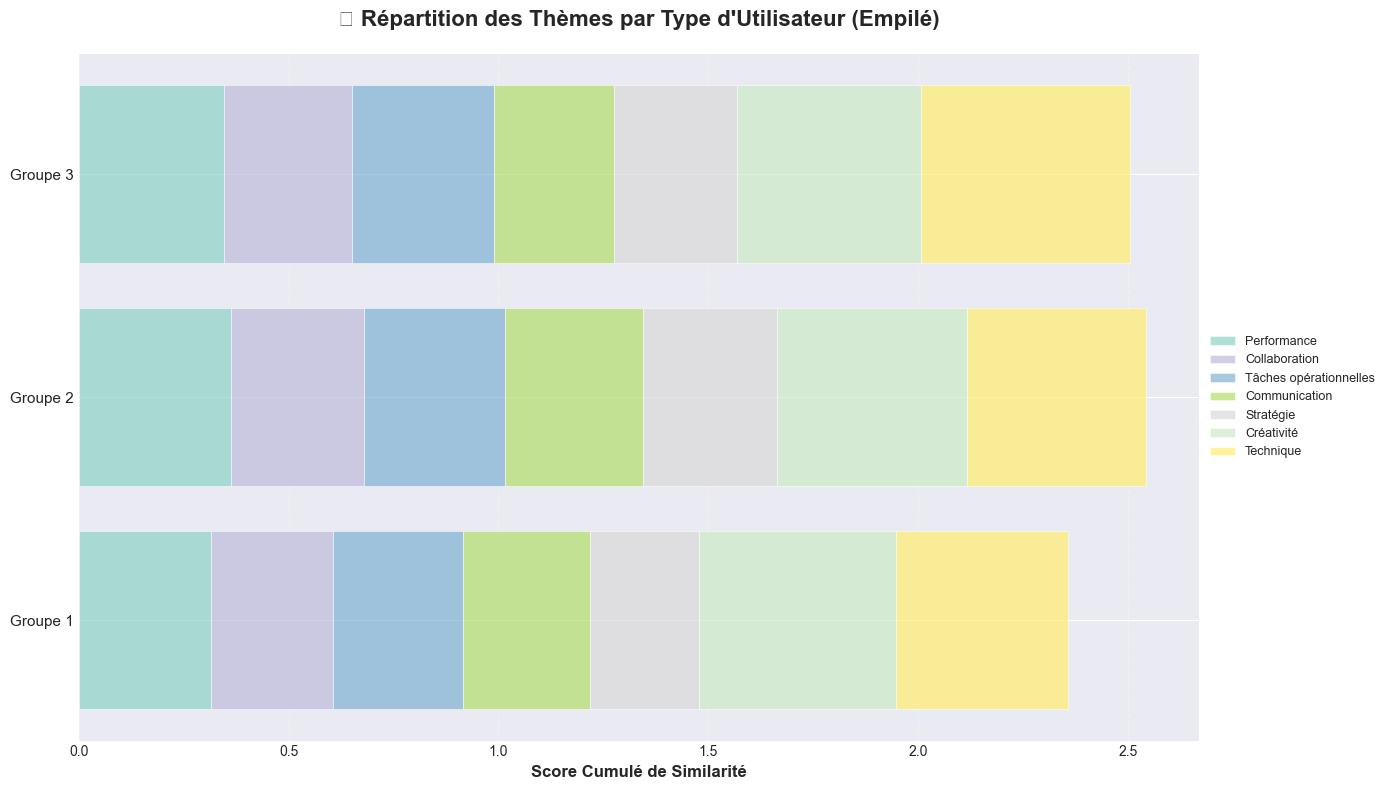

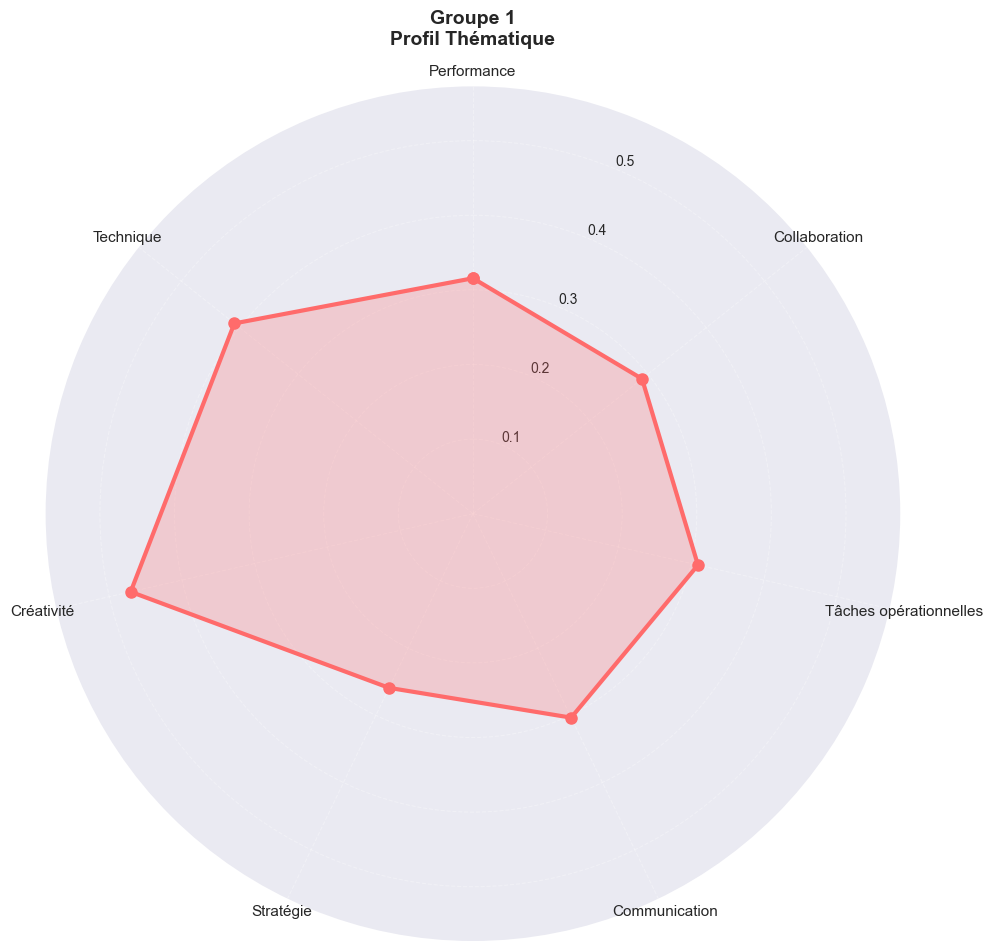

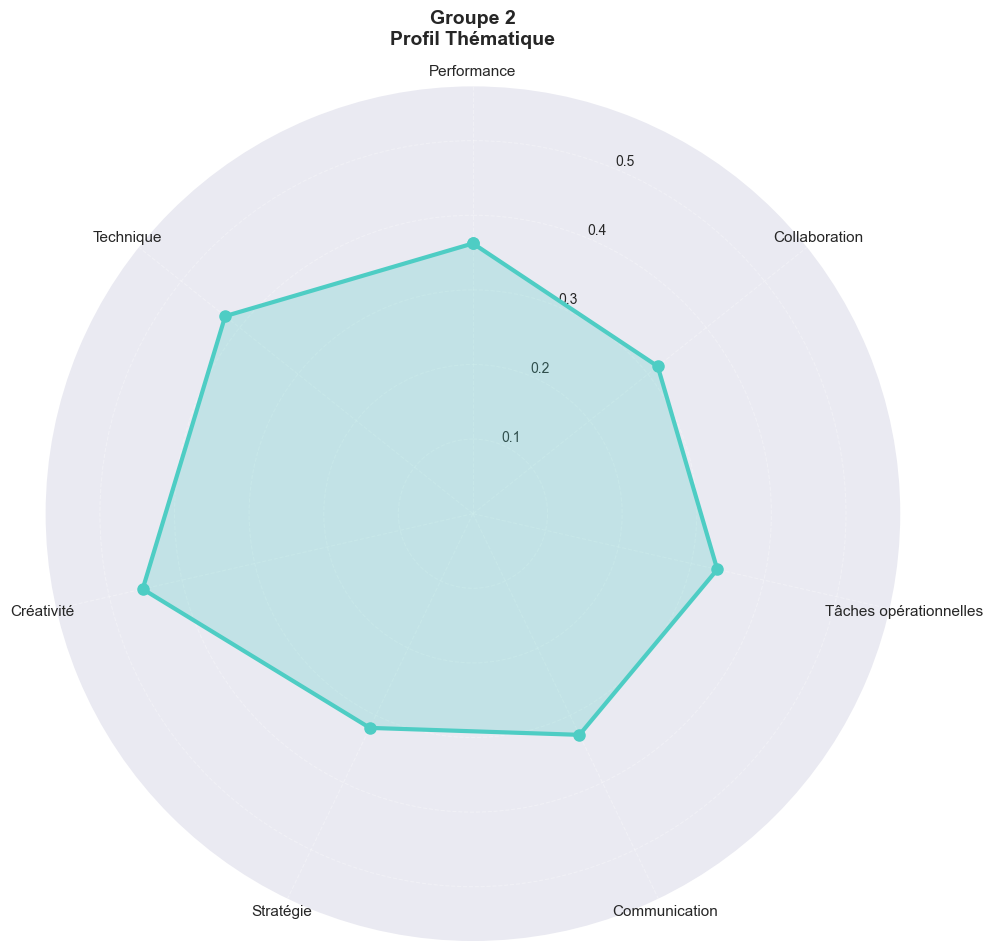

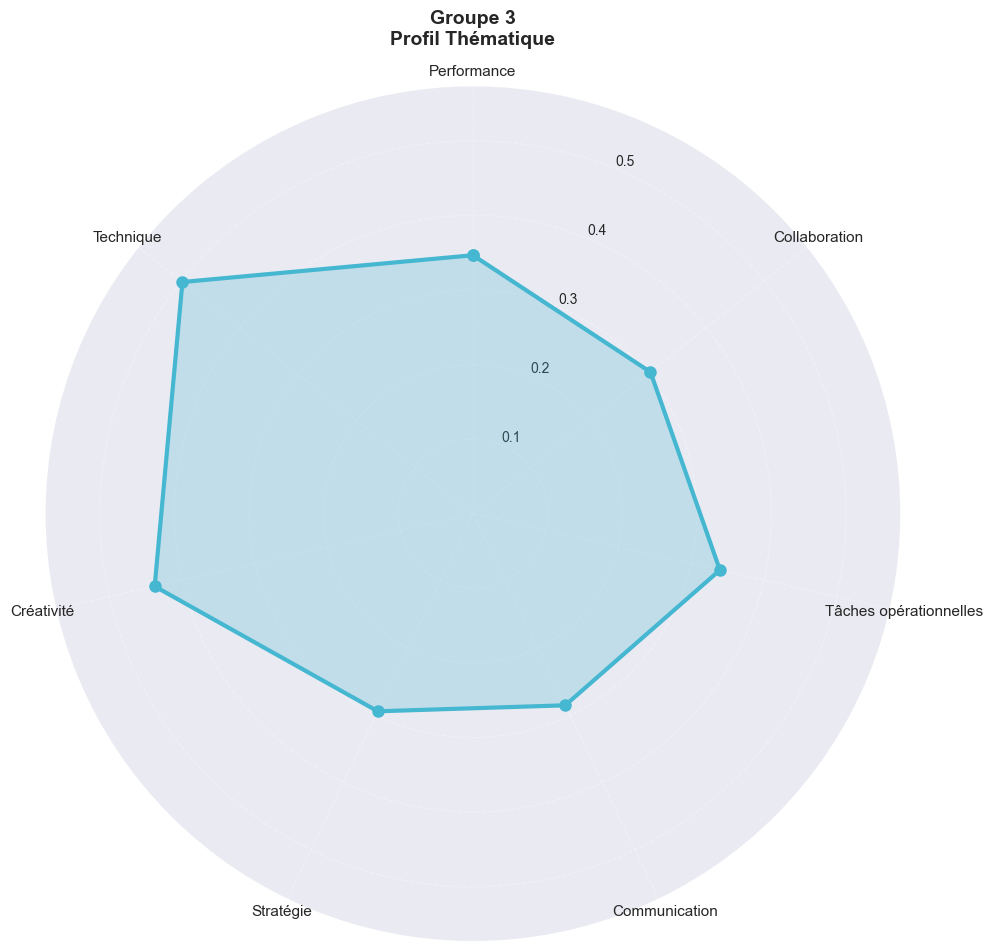


📋 TABLEAU RÉCAPITULATIF DES THÈMES PAR TYPE D'UTILISATEUR

Type d'utilisateur Performance Collaboration Tâches opérationnelles Communication Stratégie Créativité Technique
          Groupe 1       0.316         0.290                  0.309         0.303     0.259      0.471     0.409
          Groupe 2       0.362         0.317                  0.336         0.329     0.319      0.454     0.425
          Groupe 3       0.346         0.304                  0.340         0.285     0.294      0.438     0.498

--------------------------------------------------------------------------------
🎯 THÈME DOMINANT PAR TYPE D'UTILISATEUR:
--------------------------------------------------------------------------------
  Groupe 1: Créativité (score: 0.4706)
  Groupe 2: Créativité (score: 0.4540)
  Groupe 3: Technique (score: 0.4980)



In [18]:

# 1. Préparation de df_utterances à partir de l'index de df_user_only
# On crée une liste pour stocker les répliques et l'index d'origine (parent_index)
utterances_list = []
parent_indices = []

for idx, row in df_user_only.iterrows():
    # Parcourir toutes les colonnes User_Turn_*
    for col in df_user_only.columns:
        if col.startswith('User_Turn_') and pd.notna(row[col]) and str(row[col]).strip():
            utterances_list.append(str(row[col]).strip())
            parent_indices.append(idx) # On stocke l'index ici

# Création du DataFrame de travail
df_utterances = pd.DataFrame({
    'parent_index': parent_indices,
    'utterance': utterances_list
})

# 2. Injection des clusters via l'index
# On mappe le cluster de df_user_only vers df_utterances en utilisant l'index
df_utterances['cluster'] = df_utterances['parent_index'].map(df_user_only['cluster'])

# 3. Analyse Sémantique
USE_EMBEDDINGS = False
try:
    from sentence_transformers import SentenceTransformer
    USE_EMBEDDINGS = True
    print("✓ sentence-transformers disponible → Analyse des thèmes par cluster")
except ImportError:
    print("✗ sentence-transformers non disponible.")

if USE_EMBEDDINGS:
    print("Chargement du modèle sémantique...")
    model = SentenceTransformer('all-MiniLM-L6-v2')

    # Étape A — Encodage des répliques
    print(f"Calcul des embeddings pour {len(df_utterances)} répliques...")
    utterance_embeddings = model.encode(df_utterances['utterance'].tolist(), show_progress_bar=True)
    df_utterances['embedding'] = list(utterance_embeddings)

    # Étape B — Définition des thèmes théoriques
    themes = {
        'Performance': ["performance review", "evaluation", "results", "objectifs"],
        'Collaboration': ["team meeting", "collaboration", "teamwork", "colleagues"],
        'Tâches opérationnelles': ["work tasks", "project deadlines", "job duties", "tâches"],
        'Communication': ["emails", "client communication", "meetings", "presentations"],
        'Stratégie': ["sales strategy", "business strategy", "planning", "vision"],
        'Créativité': ["creative writing", "brainstorming", "ideas", "innovation"],
        'Technique': ["coding", "programming", "technical work", "software"]
    }

    # Étape C — Calcul des vecteurs moyens pour chaque thème
    theme_embeddings = {name: np.mean(model.encode(texts), axis=0) for name, texts in themes.items()}

    # Étape D — Calcul de la similarité par cluster
    print("\n=== ANALYSE DES THÈMES PAR CLUSTER ===")
    
    # Stocker les scores pour la visualisation
    cluster_scores = {}

    for cluster_id in sorted(df_utterances['cluster'].dropna().unique()):
        # Extraction des embeddings pour ce cluster
        cluster_data = df_utterances[df_utterances['cluster'] == cluster_id]
        cluster_embs_array = np.stack(cluster_data['embedding'].values)
        mean_cluster_emb = np.mean(cluster_embs_array, axis=0)

        # Calcul de la similarité cosine avec les thèmes
        scores = {name: cosine_similarity([mean_cluster_emb], [t_emb])[0][0]
                  for name, t_emb in theme_embeddings.items()}
        
        # Stocker les scores pour la visualisation
        cluster_scores[int(cluster_id)] = scores

        # Affichage
        print(f"\n📊 CLUSTER {int(cluster_id)} ({len(cluster_data)} répliques):")
        sorted_themes = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        for theme, score in sorted_themes:
            bar = "█" * int(score * 40)
            print(f"  {theme:25s} {score:.4f} {bar}")
        print(f"  → Thème dominant : {sorted_themes[0][0]}")

    # Nettoyage final pour df_work
    df_work = df_utterances[['parent_index', 'utterance', 'cluster']].copy()
    
    # ========== VISUALISATION DES THÈMES PAR CLUSTER ==========
    print("\n" + "="*80)
    print("🎨 GÉNÉRATION DES VISUALISATIONS...")
    print("="*80)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Configuration du style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Définir les noms des clusters en français
    cluster_names = {
        0: "Groupe 1",
        1: "Groupe 2",
        2: "Groupe 3"
    }
    
    # Créer un DataFrame pour faciliter la visualisation
    themes_list = list(cluster_scores[list(cluster_scores.keys())[0]].keys())
    clusters_list = sorted(cluster_scores.keys())
    
    # Créer une matrice de scores avec les noms français
    scores_matrix = []
    cluster_labels = []
    for cluster_id in clusters_list:
        row = [cluster_scores[cluster_id][theme] for theme in themes_list]
        scores_matrix.append(row)
        cluster_labels.append(cluster_names.get(cluster_id, f'Cluster {cluster_id}'))
    
    df_scores = pd.DataFrame(scores_matrix, 
                             index=cluster_labels,
                             columns=themes_list)
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F', '#BB8FCE']
    max_score = max([max(s) for s in scores_matrix])
    
    # 1. HEATMAP - Vue d'ensemble (graphique séparé)
    plt.figure(figsize=(12, 8))
    sns.heatmap(df_scores, annot=True, fmt='.3f', cmap='YlOrRd', 
                cbar_kws={'label': 'Score de similarité'}, 
                linewidths=0.5, linecolor='gray')
    plt.title('📊 Heatmap des Scores de Similarité par Thème', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Thèmes', fontsize=12, fontweight='bold')
    plt.ylabel('Types d\'utilisateurs', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # 2. Graphiques en barres groupées (graphique séparé)
    plt.figure(figsize=(14, 8))
    x = np.arange(len(themes_list))
    width = 0.25
    
    for i, cluster_id in enumerate(clusters_list):
        offset = (i - len(clusters_list)/2 + 0.5) * width
        scores = [cluster_scores[cluster_id][theme] for theme in themes_list]
        plt.bar(x + offset, scores, width, label=cluster_names.get(cluster_id, f'Cluster {cluster_id}'), 
                color=colors[i % len(colors)], alpha=0.8, edgecolor='black', linewidth=0.5)
    
    plt.xlabel('Thèmes', fontsize=12, fontweight='bold')
    plt.ylabel('Score de Similarité', fontsize=12, fontweight='bold')
    plt.title('📊 Comparaison des Thèmes par Type d\'Utilisateur', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(x, themes_list, rotation=45, ha='right', fontsize=10)
    plt.legend(loc='upper left', fontsize=10, framealpha=0.9)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.ylim([0, max_score * 1.15])
    plt.tight_layout()
    plt.show()
    
    # 3. Graphiques en barres horizontales empilées (graphique séparé)
    plt.figure(figsize=(14, 8))
    cluster_positions = np.arange(len(clusters_list))
    theme_colors = plt.cm.Set3(np.linspace(0, 1, len(themes_list)))
    
    bottom = np.zeros(len(clusters_list))
    for i, theme in enumerate(themes_list):
        values = [cluster_scores[cluster_id][theme] for cluster_id in clusters_list]
        plt.barh(cluster_positions, values, left=bottom, label=theme, 
                color=theme_colors[i], alpha=0.7, edgecolor='white', linewidth=0.5)
        bottom += values
    
    plt.yticks(cluster_positions, cluster_labels, fontsize=11)
    plt.xlabel('Score Cumulé de Similarité', fontsize=12, fontweight='bold')
    plt.title('📊 Répartition des Thèmes par Type d\'Utilisateur (Empilé)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9, framealpha=0.9)
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # 4. Graphiques radar (spider charts) - un graphique par cluster
    angles = np.linspace(0, 2 * np.pi, len(themes_list), endpoint=False).tolist()
    angles += angles[:1]  # Fermer le cercle
    
    for idx, cluster_id in enumerate(clusters_list):
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
        
        scores = [cluster_scores[cluster_id][theme] for theme in themes_list]
        scores += scores[:1]  # Fermer le cercle
        
        # Tracer le radar
        ax.plot(angles, scores, 'o-', linewidth=3, 
               color=colors[idx % len(colors)], markersize=8)
        ax.fill(angles, scores, alpha=0.25, color=colors[idx % len(colors)])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(themes_list, fontsize=11)
        ax.set_ylim(0, max_score * 1.15)
        ax.set_title(cluster_names.get(cluster_id, f'Cluster {cluster_id}') + '\nProfil Thématique', 
                    fontsize=14, fontweight='bold', pad=30)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        
        plt.tight_layout()
        plt.show()
    
    # 5. Tableau récapitulatif stylisé
    print("\n" + "="*80)
    print("📋 TABLEAU RÉCAPITULATIF DES THÈMES PAR TYPE D'UTILISATEUR")
    print("="*80)
    
    # Créer un tableau avec les scores
    summary_data = []
    for cluster_id in clusters_list:
        row = [cluster_names.get(cluster_id, f'Cluster {cluster_id}')]
        scores = [cluster_scores[cluster_id][theme] for theme in themes_list]
        row.extend([f'{s:.3f}' for s in scores])
        summary_data.append(row)
    
    summary_df = pd.DataFrame(summary_data, 
                             columns=['Type d\'utilisateur'] + themes_list)
    print("\n" + summary_df.to_string(index=False))
    
    # Afficher le thème dominant par cluster
    print("\n" + "-"*80)
    print("🎯 THÈME DOMINANT PAR TYPE D'UTILISATEUR:")
    print("-"*80)
    for cluster_id in clusters_list:
        scores = cluster_scores[cluster_id]
        dominant_theme = max(scores.items(), key=lambda x: x[1])
        cluster_name = cluster_names.get(cluster_id, f'Cluster {cluster_id}')
        print(f"  {cluster_name}: {dominant_theme[0]} (score: {dominant_theme[1]:.4f})")
    
    print("\n" + "="*80)




### 5.5 Configuration LLM pour Analyses Avancées

Cette section configure l'utilisation d'un LLM (Gemini) comme annotateur contrôlé pour enrichir les analyses avec des annotations structurées (JSON uniquement).

In [19]:
# === LLM SETUP + API KEY ===

import os
import json
from pathlib import Path

# Tentative de chargement depuis .env si disponible
try:
    from dotenv import load_dotenv
    load_dotenv()
    print("✓ python-dotenv disponible, chargement de .env si présent")
except ImportError:
    print("⚠ python-dotenv non disponible, utilisation des variables d'environnement système uniquement")

# Configuration du provider LLM
LLM_PROVIDER = "gemini"  # Peut être changé pour "openai", "anthropic", etc.

# Récupération de la clé API
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")

# Vérification et configuration
if not GEMINI_API_KEY or GEMINI_API_KEY.strip() == "":
    print("⚠ GEMINI_API_KEY non définie dans les variables d'environnement")
    print("   → Mode NO-LLM activé : analyses basées uniquement sur embeddings")
    USE_LLM = False
else:
    print("✓ GEMINI_API_KEY détectée")
    USE_LLM = True
    # Ne jamais afficher la clé
    print(f"   Provider: {LLM_PROVIDER}")

print(f"\nMode d'exécution: {'LLM + Embeddings' if USE_LLM else 'Embeddings uniquement'}")


⚠ python-dotenv non disponible, utilisation des variables d'environnement système uniquement
✓ GEMINI_API_KEY détectée
   Provider: gemini

Mode d'exécution: LLM + Embeddings


In [21]:
# === LLM CLIENT + BATCHING + CACHE ===

import hashlib
import time
import requests
from typing import List, Dict, Optional
import json

# Configuration du cache
CACHE_DIR = Path("data/processed")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = CACHE_DIR / "llm_cache.json"
BATCH_SIZE = 8  # Nombre d'excerpts par batch

# Charger le cache existant
llm_cache = {}
if CACHE_FILE.exists():
    try:
        with open(CACHE_FILE, 'r', encoding='utf-8') as f:
            llm_cache = json.load(f)
        print(f"✓ Cache chargé: {len(llm_cache)} entrées")
    except Exception as e:
        print(f"⚠ Erreur lors du chargement du cache: {e}")
        llm_cache = {}
else:
    print("✓ Nouveau cache créé")

def hash_excerpt(text: str) -> str:
    """Génère un hash SHA256 pour un excerpt"""
    return hashlib.sha256(text.encode('utf-8')).hexdigest()

def validate_json_schema(output: List[Dict]) -> bool:
    """Valide que la sortie JSON a le schéma attendu"""
    required_fields = [
        'identity_signal', 'adaptation_strategy', 'normative_discourse',
        'descriptive_practice', 'dissonance_signal', 'stigma_signal',
        'inequality_positioning', 'trust_level_ai', 'justification'
    ]
    
    if not isinstance(output, list):
        return False
    
    for item in output:
        if not isinstance(item, dict):
            return False
        for field in required_fields:
            if field not in item:
                return False
    
    return True

# Prompt pour l'annotation JSON
FINAL_ANNOTATION_PROMPT = """You are a research assistant analyzing interview excerpts about AI in the workplace.

For each excerpt below, annotate it INDEPENDENTLY. Do NOT use external knowledge or make global inferences. 
Base your annotation ONLY on what is explicitly stated or clearly implied in that specific excerpt.

For each excerpt, return a JSON object with these exact fields:
- identity_signal: "yes" or "no" (mentions of professional identity, core job definition, refusal to delegate)
- adaptation_strategy: "resistance" or "hybridation" or "requalification" or "contournement" or "exit" or "none"
- normative_discourse: "yes" or "no" (statements about what should be done, moral boundaries)
- descriptive_practice: "yes" or "no" (statements about what is actually done in practice)
- dissonance_signal: "yes" or "no" (conflict between normative and descriptive, contradictions)
- stigma_signal: "yes" or "no" (mentions of judgment, hiding usage, peer criticism)
- inequality_positioning: "advantage" or "survival_pressure" or "neutral"
- trust_level_ai: "high" or "medium" or "low" or "not_applicable"
- justification: brief explanation (max 20 words)

Return ONLY a JSON array of objects, one per excerpt, in the same order. No other text.


Excerpts:
{excerpts}
"""
def call_llm_json(excerpts: List[str]) -> List[Dict]:
    """
    Appelle le LLM pour annoter des excerpts et retourne une liste de dictionnaires JSON.
    Utilise le cache pour éviter les appels répétés.
    """
    if not USE_LLM:
        # Mode sans LLM : retourner des annotations par défaut
        return [{
            'identity_signal': 'no',
            'adaptation_strategy': 'none',
            'normative_discourse': 'no',
            'descriptive_practice': 'no',
            'dissonance_signal': 'no',
            'stigma_signal': 'no',
            'inequality_positioning': 'neutral',
            'trust_level_ai': 'not_applicable',
            'justification': 'LLM not available'
        } for _ in excerpts]
    
    # Vérifier le cache pour chaque excerpt
    results = []
    uncached_excerpts = []
    uncached_indices = []
    
    for idx, excerpt in enumerate(excerpts):
        cache_key = hash_excerpt(excerpt)
        if cache_key in llm_cache:
            results.append((idx, llm_cache[cache_key]))
        else:
            uncached_excerpts.append(excerpt)
            uncached_indices.append(idx)
    
    # Appeler l'API pour les excerpts non cachés
    if uncached_excerpts:
        if LLM_PROVIDER == "gemini":
            # Utilisation de l'API Gemini via HTTP
            try:
                url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?key={GEMINI_API_KEY}"
                
                # Préparer le prompt
                excerpts_text = "\n\n".join([f"Excerpt {i+1}: {ex}" for i, ex in enumerate(uncached_excerpts)])
                prompt_text = FINAL_ANNOTATION_PROMPT.format(excerpts=excerpts_text)
                
                payload = {
                    "contents": [{
                        "parts": [{"text": prompt_text}]
                    }]
                }
                
                response = requests.post(url, json=payload, timeout=60)
                response.raise_for_status()
                
                # Extraire le texte de la réponse
                response_data = response.json()
                if 'candidates' in response_data and len(response_data['candidates']) > 0:
                    content = response_data['candidates'][0]['content']['parts'][0]['text']
                    
                    # Nettoyer et parser le JSON
                    # Enlever markdown code blocks si présents
                    content = content.strip()
                    if content.startswith("```"):
                        lines = content.split("\n")
                        content = "\n".join(lines[1:-1]) if len(lines) > 2 else content
                    if content.startswith("```json"):
                        lines = content.split("\n")
                        content = "\n".join(lines[1:-1]) if len(lines) > 2 else content
                    
                    try:
                        api_results = json.loads(content)
                        if not isinstance(api_results, list):
                            api_results = [api_results]
                    except json.JSONDecodeError:
                        # Retry avec instruction plus stricte
                        retry_prompt = prompt_text + "\n\nIMPORTANT: Return ONLY valid JSON array, no other text."
                        payload["contents"][0]["parts"][0]["text"] = retry_prompt
                        retry_response = requests.post(url, json=payload, timeout=60)
                        retry_data = retry_response.json()
                        if 'candidates' in retry_data:
                            retry_content = retry_data['candidates'][0]['content']['parts'][0]['text']
                            retry_content = retry_content.strip().replace("```json", "").replace("```", "").strip()
                            try:
                                api_results = json.loads(retry_content)
                                if not isinstance(api_results, list):
                                    api_results = [api_results]
                            except:
                                api_results = None
                        else:
                            api_results = None
                    
                    if api_results and validate_json_schema(api_results):
                        # Mettre en cache et ajouter aux résultats
                        for i, (orig_idx, result) in enumerate(zip(uncached_indices, api_results)):
                            cache_key = hash_excerpt(uncached_excerpts[i])
                            llm_cache[cache_key] = result
                            results.append((orig_idx, result))
                    else:
                        # Annotation par défaut en cas d'erreur
                        print(f"⚠ Erreur de parsing JSON pour {len(uncached_excerpts)} excerpts, utilisation de valeurs par défaut")
                        for i, orig_idx in enumerate(uncached_indices):
                            default_result = {
                                'identity_signal': 'no',
                                'adaptation_strategy': 'none',
                                'normative_discourse': 'no',
                                'descriptive_practice': 'no',
                                'dissonance_signal': 'no',
                                'stigma_signal': 'no',
                                'inequality_positioning': 'neutral',
                                'trust_level_ai': 'not_applicable',
                                'justification': 'API parsing error'
                            }
                            cache_key = hash_excerpt(uncached_excerpts[i])
                            llm_cache[cache_key] = default_result
                            results.append((orig_idx, default_result))
                
                # Sauvegarder le cache
                with open(CACHE_FILE, 'w', encoding='utf-8') as f:
                    json.dump(llm_cache, f, indent=2, ensure_ascii=False)
                
            except Exception as e:
                print(f"⚠ Erreur API Gemini: {e}")
                # Fallback : annotations par défaut
                for i, orig_idx in enumerate(uncached_indices):
                    default_result = {
                        'identity_signal': 'no',
                        'adaptation_strategy': 'none',
                        'normative_discourse': 'no',
                        'descriptive_practice': 'no',
                        'dissonance_signal': 'no',
                        'stigma_signal': 'no',
                        'inequality_positioning': 'neutral',
                        'trust_level_ai': 'not_applicable',
                        'justification': f'API error: {str(e)[:30]}'
                    }
                    results.append((orig_idx, default_result))
        else:
            # Autres providers (à implémenter si nécessaire)
            print(f"⚠ Provider {LLM_PROVIDER} non implémenté, utilisation de valeurs par défaut")
            for i, orig_idx in enumerate(uncached_indices):
                default_result = {
                    'identity_signal': 'no',
                    'adaptation_strategy': 'none',
                    'normative_discourse': 'no',
                    'descriptive_practice': 'no',
                    'dissonance_signal': 'no',
                    'stigma_signal': 'no',
                    'inequality_positioning': 'neutral',
                    'trust_level_ai': 'not_applicable',
                    'justification': 'Provider not implemented'
                }
                results.append((orig_idx, default_result))
    
    # Trier par index original et retourner uniquement les valeurs
    results.sort(key=lambda x: x[0])
    return [r[1] for r in results]

print(f"✓ Fonction call_llm_json configurée")
print(f"  - Cache: {len(llm_cache)} entrées")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Provider: {LLM_PROVIDER}")


✓ Nouveau cache créé
✓ Fonction call_llm_json configurée
  - Cache: 0 entrées
  - Batch size: 8
  - Provider: gemini


In [22]:
# === PROTOTYPE EMBEDDINGS (ANCHORS) ===

"""
Cette cellule calcule des embeddings d'ancrage (prototypes sémantiques) pour filtrer
les répliques avant annotation LLM. On utilise des phrases complètes comme ancres,
pas des mots-clés, pour capturer la sémantique.
"""

print("=== CALCUL DES EMBEDDINGS D'ANCRAGE ===\n")

# Vérifier que df_utterances et les embeddings existent
if 'df_utterances' not in globals() or 'embedding' not in df_utterances.columns:
    print("⚠ df_utterances ou embeddings non disponibles. Vérifiez que la section 5.4 a été exécutée.")
else:
    print(f"✓ Utilisation des embeddings existants de df_utterances ({len(df_utterances)} répliques)")
    
    # Définir les ancres sémantiques (phrases complètes, pas mots-clés)
    anchor_sentences = {
        'identity': [
            "What defines me as a professional is the core work I do myself",
            "I refuse to delegate tasks that are central to my professional identity",
            "The meaning of my work comes from doing these tasks personally",
            "Ce qui me définit professionnellement, c'est ce que je fais moi-même",
            "Je refuse de déléguer ce qui fait le cœur de mon métier"
        ],
        'adaptation': [
            "I am learning new skills to adapt to AI in my field",
            "I supervise AI systems rather than doing the work myself",
            "I use AI secretly without telling my colleagues",
            "I am considering changing careers because of AI",
            "J'apprends de nouvelles compétences pour m'adapter à l'IA",
            "Je supervise les systèmes IA plutôt que de faire le travail moi-même"
        ],
        'dissonance': [
            "I should maintain control but in practice AI often decides",
            "I say I keep boundaries but actually I delegate a lot",
            "Je dis que je garde le contrôle mais en réalité l'IA décide souvent"
        ],
        'stigma': [
            "My colleagues judge me for using AI tools",
            "I hide my AI usage because people think it's lazy",
            "I feel embarrassed about relying on AI",
            "Mes collègues me jugent pour mon utilisation de l'IA",
            "Je cache mon usage de l'IA car les gens pensent que c'est de la paresse"
        ],
        'inequality': [
            "AI gives me a competitive advantage and I produce much more",
            "I must adapt to survive because the market is saturated",
            "AI helps me stay ahead of competitors",
            "L'IA me donne un avantage concurrentiel",
            "Je dois m'adapter pour survivre car le marché est saturé"
        ]
    }
    
    # Calculer les embeddings des ancres
    print("Calcul des embeddings pour les ancres sémantiques...")
    anchor_embeddings = {}
    for category, sentences in anchor_sentences.items():
        # Utiliser le même modèle que pour df_utterances
        if USE_EMBEDDINGS and 'model' in globals():
            anchor_embs = model.encode(sentences)
            anchor_embeddings[category] = np.mean(anchor_embs, axis=0)
            print(f"  ✓ {category}: {len(sentences)} ancres → embedding moyen calculé")
        else:
            print(f"  ⚠ Modèle non disponible pour {category}")
    
    # Calculer la similarité cosine entre chaque réplique et chaque ancre
    print("\nCalcul des similarités avec les ancres...")
    
    # Convertir les embeddings en array numpy si nécessaire
    if isinstance(df_utterances['embedding'].iloc[0], list):
        utterance_embeddings_array = np.array(df_utterances['embedding'].tolist())
    else:
        utterance_embeddings_array = np.stack(df_utterances['embedding'].values)
    
    # Calculer les similarités
    for category, anchor_emb in anchor_embeddings.items():
        similarities = cosine_similarity(utterance_embeddings_array, [anchor_emb]).flatten()
        df_utterances[f'sim_{category}'] = similarities
    
    print(f"\n✓ Similarités calculées pour {len(anchor_embeddings)} catégories")
    print(f"  Colonnes ajoutées: {[f'sim_{cat}' for cat in anchor_embeddings.keys()]}")
    
    # Afficher quelques statistiques
    print("\n=== STATISTIQUES DES SIMILARITÉS ===")
    for category in anchor_embeddings.keys():
        col = f'sim_{category}'
        print(f"{category}: min={df_utterances[col].min():.3f}, max={df_utterances[col].max():.3f}, mean={df_utterances[col].mean():.3f}")
    
    print("\n✓ Embeddings d'ancrage configurés et similarités calculées")

=== CALCUL DES EMBEDDINGS D'ANCRAGE ===

✓ Utilisation des embeddings existants de df_utterances (11983 répliques)
Calcul des embeddings pour les ancres sémantiques...
  ✓ identity: 5 ancres → embedding moyen calculé
  ✓ adaptation: 6 ancres → embedding moyen calculé
  ✓ dissonance: 3 ancres → embedding moyen calculé
  ✓ stigma: 5 ancres → embedding moyen calculé
  ✓ inequality: 5 ancres → embedding moyen calculé

Calcul des similarités avec les ancres...

✓ Similarités calculées pour 5 catégories
  Colonnes ajoutées: ['sim_identity', 'sim_adaptation', 'sim_dissonance', 'sim_stigma', 'sim_inequality']

=== STATISTIQUES DES SIMILARITÉS ===
identity: min=-0.155, max=0.483, mean=0.135
adaptation: min=-0.112, max=0.744, mean=0.344
dissonance: min=-0.186, max=0.622, mean=0.224
stigma: min=-0.187, max=0.692, mean=0.314
inequality: min=-0.186, max=0.579, mean=0.217

✓ Embeddings d'ancrage configurés et similarités calculées


## 6. Analyses Avancées - Transformations Profondes du Travail

**⚠️ IMPORTANT :** La cellule ci-dessous calcule maintenant le **pourcentage d'utilisateurs fragiles par cluster** (normalisé) au lieu de nombres absolus, pour éviter le biais lié à la taille des clusters.

=== DISTRIBUTION DES UTILISATEURS PAR CLUSTER ===

Nombre d'utilisateurs (entretiens) par cluster :
--------------------------------------------------
Cluster 0: 130 utilisateurs (13.0%)
Cluster 1: 719 utilisateurs (71.9%)
Cluster 2: 151 utilisateurs (15.1%)
--------------------------------------------------
Total: 1000 utilisateurs


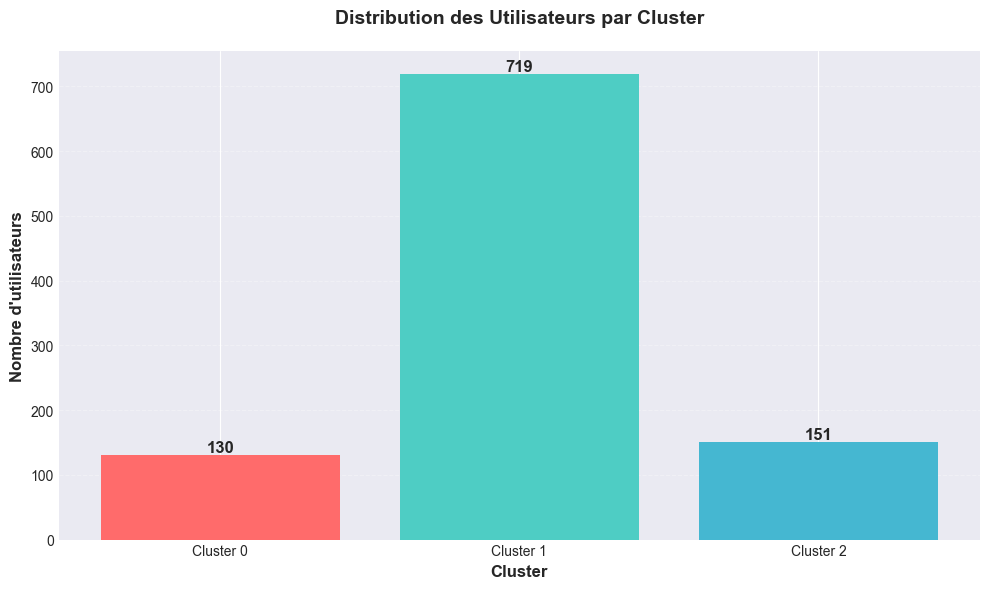


✓ Réponse : 719 utilisateurs sont dans le cluster 1


In [23]:
# Distribution des utilisateurs par cluster
print("=== DISTRIBUTION DES UTILISATEURS PAR CLUSTER ===\n")

if 'cluster' in df_user_only.columns:
    cluster_distribution = df_user_only['cluster'].value_counts().sort_index()
    
    print("Nombre d'utilisateurs (entretiens) par cluster :")
    print("-" * 50)
    for cluster_id in sorted(cluster_distribution.index):
        count = cluster_distribution[cluster_id]
        percentage = (count / len(df_user_only)) * 100
        print(f"Cluster {int(cluster_id)}: {count} utilisateurs ({percentage:.1f}%)")
    print("-" * 50)
    print(f"Total: {len(df_user_only)} utilisateurs")
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    bars = plt.bar([f'Cluster {int(c)}' for c in cluster_distribution.index], 
                    cluster_distribution.values,
                    color=colors[:len(cluster_distribution)])
    
    # Ajouter les valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.title('Distribution des Utilisateurs par Cluster', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Cluster', fontsize=12, fontweight='bold')
    plt.ylabel('Nombre d\'utilisateurs', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # Réponse directe à la question
    if 1 in cluster_distribution.index:
        print(f"\n✓ Réponse : {int(cluster_distribution[1])} utilisateurs sont dans le cluster 1")
    else:
        print("\n⚠ Cluster 1 n'existe pas dans les données")
else:
    print("⚠ La colonne 'cluster' n'existe pas encore. Exécutez d'abord la cellule de clustering.")

### 6.1 Évolution des discours dans l'entretien

=== 6.1 ÉVOLUTION DES DISCOURS DANS L'ENTRETIEN ===

Nombre total de répliques analysées: 11983
Nombre d'entretiens: 1000

Répartition par segment:
segment
fin       4655
début     3665
milieu    3663
Name: count, dtype: int64

Chargement du modèle sémantique...
Calcul des embeddings...

=== ÉVOLUTION DES THÈMES PAR SEGMENT ===

DÉBUT (3665 répliques):
  Anxiété: 0.1107
  Optimisme: 0.1224
  Contrôle: 0.1553
  Dépendance: 0.1511
  Stratégie: 0.1548

MILIEU (3663 répliques):
  Anxiété: 0.0589
  Optimisme: 0.0729
  Contrôle: 0.1568
  Dépendance: 0.1421
  Stratégie: 0.1264

FIN (4655 répliques):
  Anxiété: 0.0619
  Optimisme: 0.0764
  Contrôle: 0.1544
  Dépendance: 0.1305
  Stratégie: 0.1250


C:\Users\Khyro\AppData\Local\Temp\ipykernel_25300\787246146.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=segments_order, patch_artist=True)
C:\Users\Khyro\AppData\Local\Temp\ipykernel_25300\787246146.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=segments_order, patch_artist=True)
C:\Users\Khyro\AppData\Local\Temp\ipykernel_25300\787246146.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=segments_order, patch_artist=True)
C:\Users\Khyro\AppData\Local\Temp\ipykernel_25300\787246146.py:101:

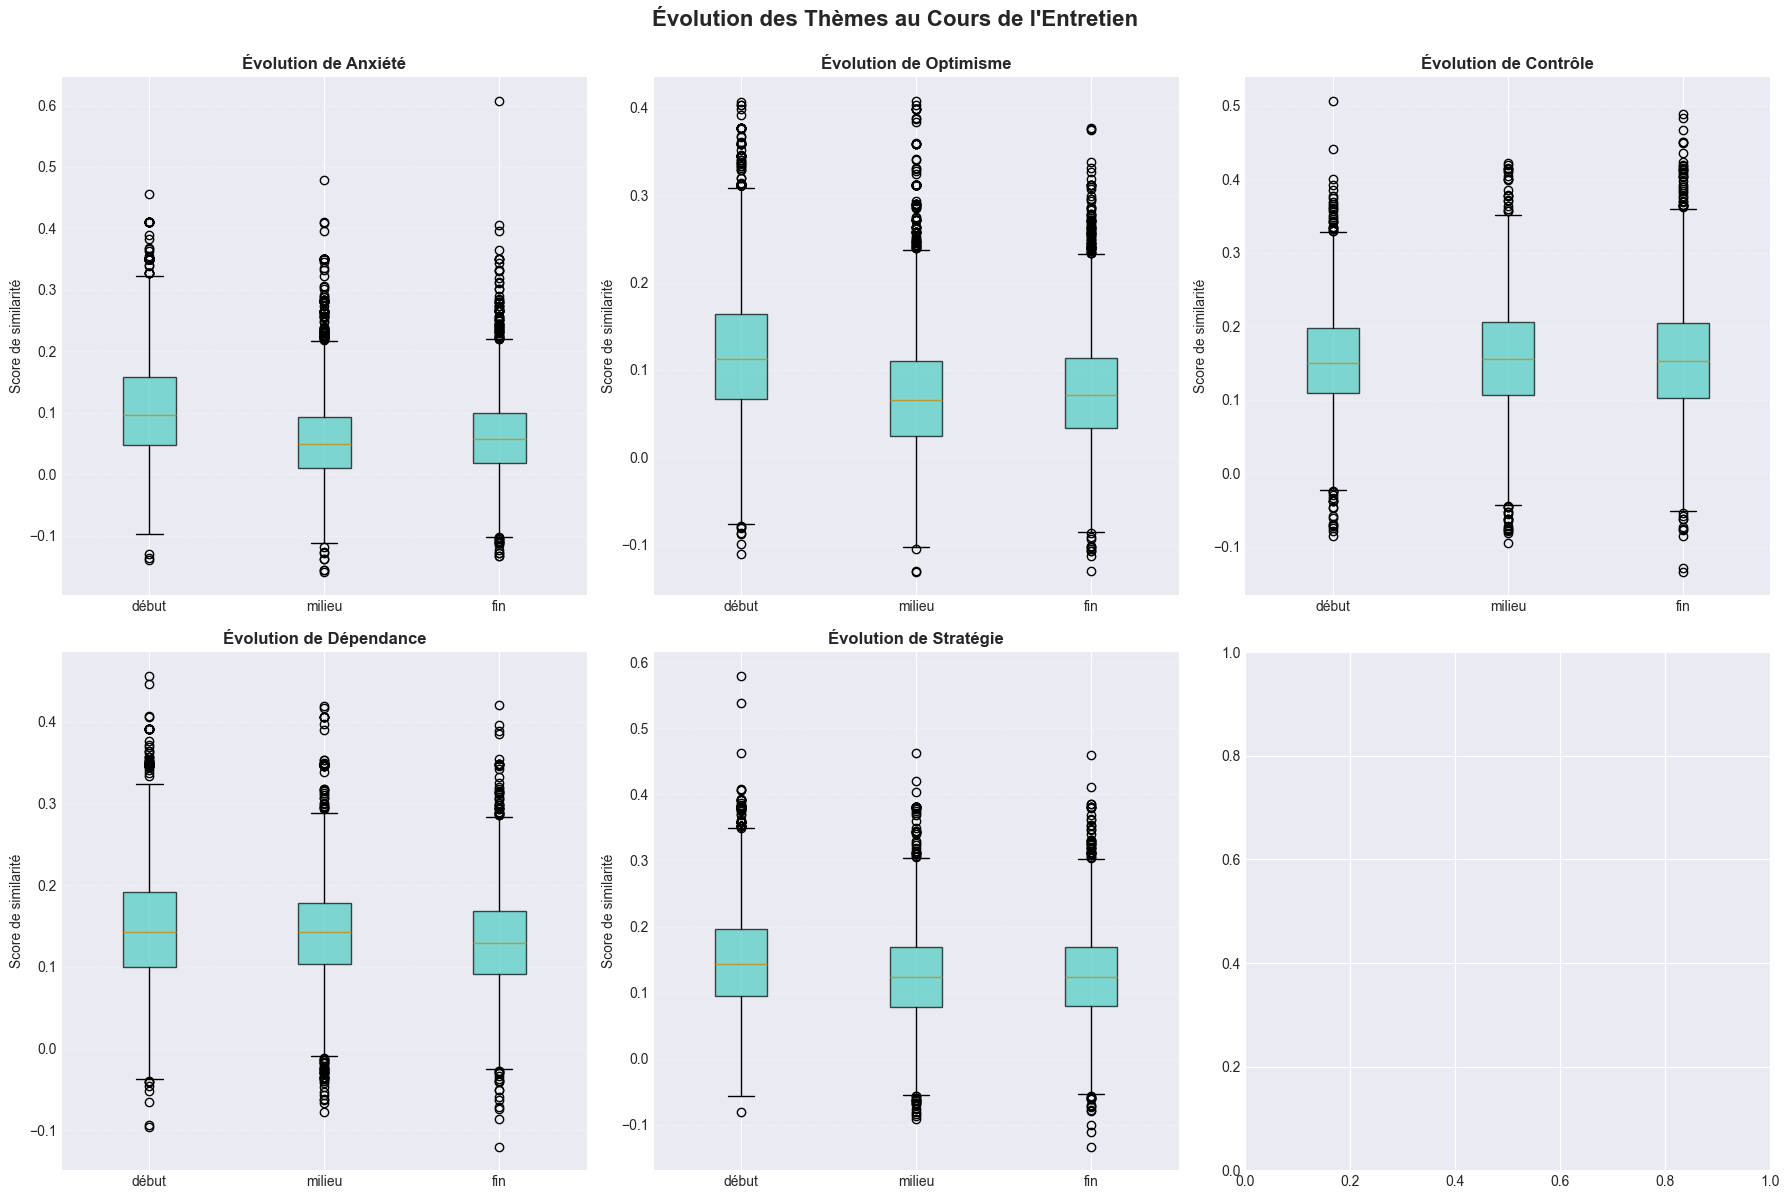


=== IDENTIFICATION DES MOMENTS DE BASCULE ===

Thèmes avec la plus forte évolution (fin - début):
                mean       std  count
theme                                
Contrôle   -0.001476  0.050230    998
Dépendance -0.022469  0.051780    998
Stratégie  -0.029992  0.059991    998
Optimisme  -0.047041  0.055140    998
Anxiété    -0.050024  0.058801    998

✓ Analyse de l'évolution temporelle terminée


In [24]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 6.1 ÉVOLUTION DES DISCOURS DANS L'ENTRETIEN ===\n")

# Préparation : créer un DataFrame avec les répliques ordonnées par position dans l'entretien
evolution_data = []

for idx, row in df_user_only.iterrows():
    transcript_id = row.get('transcript_id', f'row_{idx}')
    user_turns = []
    
    # Collecter toutes les répliques User dans l'ordre
    for col in sorted(df_user_only.columns):
        if col.startswith('User_Turn_') and pd.notna(row[col]) and str(row[col]).strip():
            turn_num = int(col.split('_')[-1])
            user_turns.append({
                'transcript_id': transcript_id,
                'turn_number': turn_num,
                'utterance': str(row[col]).strip(),
                'cluster': row.get('cluster', None)
            })
    
    # Diviser en segments : début (33%), milieu (33%), fin (33%)
    if len(user_turns) > 0:
        n = len(user_turns)
        third = max(1, n // 3)
        
        for i, turn in enumerate(user_turns):
            if i < third:
                segment = 'début'
            elif i < 2 * third:
                segment = 'milieu'
            else:
                segment = 'fin'
            
            evolution_data.append({
                **turn,
                'segment': segment,
                'position_relative': i / max(1, n-1)  # 0 à 1
            })

df_evolution = pd.DataFrame(evolution_data)

print(f"Nombre total de répliques analysées: {len(df_evolution)}")
print(f"Nombre d'entretiens: {df_evolution['transcript_id'].nunique()}")
print(f"\nRépartition par segment:")
print(df_evolution['segment'].value_counts())

# Charger le modèle sémantique
print("\nChargement du modèle sémantique...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# Calculer les embeddings pour chaque réplique
print("Calcul des embeddings...")
df_evolution['embedding'] = df_evolution['utterance'].apply(
    lambda x: model.encode([x])[0] if isinstance(x, str) else None
)

# Définir des thèmes pour analyser l'évolution
themes_evolution = {
    'Anxiété': ["worry", "anxious", "concerned", "fear", "afraid", "worried"],
    'Optimisme': ["optimistic", "hopeful", "positive", "excited", "confident"],
    'Contrôle': ["control", "oversee", "manage", "supervise", "direct"],
    'Dépendance': ["depend", "rely", "need", "essential", "can't without"],
    'Stratégie': ["strategy", "adapt", "learn", "change", "evolve", "transition"]
}

# Calculer la similarité avec chaque thème
for theme_name, keywords in themes_evolution.items():
    theme_emb = np.mean(model.encode(keywords), axis=0)
    df_evolution[f'similarity_{theme_name}'] = df_evolution['embedding'].apply(
        lambda emb: cosine_similarity([emb], [theme_emb])[0][0] if emb is not None else 0
    )

# Analyse par segment
print("\n=== ÉVOLUTION DES THÈMES PAR SEGMENT ===")
for segment in ['début', 'milieu', 'fin']:
    seg_data = df_evolution[df_evolution['segment'] == segment]
    print(f"\n{segment.upper()} ({len(seg_data)} répliques):")
    for theme in themes_evolution.keys():
        mean_score = seg_data[f'similarity_{theme}'].mean()
        print(f"  {theme}: {mean_score:.4f}")

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, theme in enumerate(themes_evolution.keys()):
    ax = axes[idx]
    
    # Boxplot par segment
    segments_order = ['début', 'milieu', 'fin']
    data_to_plot = [df_evolution[df_evolution['segment'] == seg][f'similarity_{theme}'].values 
                    for seg in segments_order]
    
    bp = ax.boxplot(data_to_plot, labels=segments_order, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#4ECDC4')
        patch.set_alpha(0.7)
    
    ax.set_title(f'Évolution de {theme}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score de similarité', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Évolution des Thèmes au Cours de l\'Entretien', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Analyse des "moments de bascule"
print("\n=== IDENTIFICATION DES MOMENTS DE BASCULE ===")
# Calculer la différence entre début et fin pour chaque thème
bascule_data = []
for transcript_id in df_evolution['transcript_id'].unique():
    transcript_data = df_evolution[df_evolution['transcript_id'] == transcript_id].sort_values('turn_number')
    if len(transcript_data) > 1:
        debut = transcript_data[transcript_data['segment'] == 'début']
        fin = transcript_data[transcript_data['segment'] == 'fin']
        
        if len(debut) > 0 and len(fin) > 0:
            for theme in themes_evolution.keys():
                diff = fin[f'similarity_{theme}'].mean() - debut[f'similarity_{theme}'].mean()
                bascule_data.append({
                    'transcript_id': transcript_id,
                    'theme': theme,
                    'evolution': diff
                })

df_bascule = pd.DataFrame(bascule_data)
if len(df_bascule) > 0:
    print("\nThèmes avec la plus forte évolution (fin - début):")
    evolution_summary = df_bascule.groupby('theme')['evolution'].agg(['mean', 'std', 'count'])
    evolution_summary = evolution_summary.sort_values('mean', ascending=False)
    print(evolution_summary)

print("\n✓ Analyse de l'évolution temporelle terminée")


=== GÉNÉRATION DES COURBES D'ÉVOLUTION ===



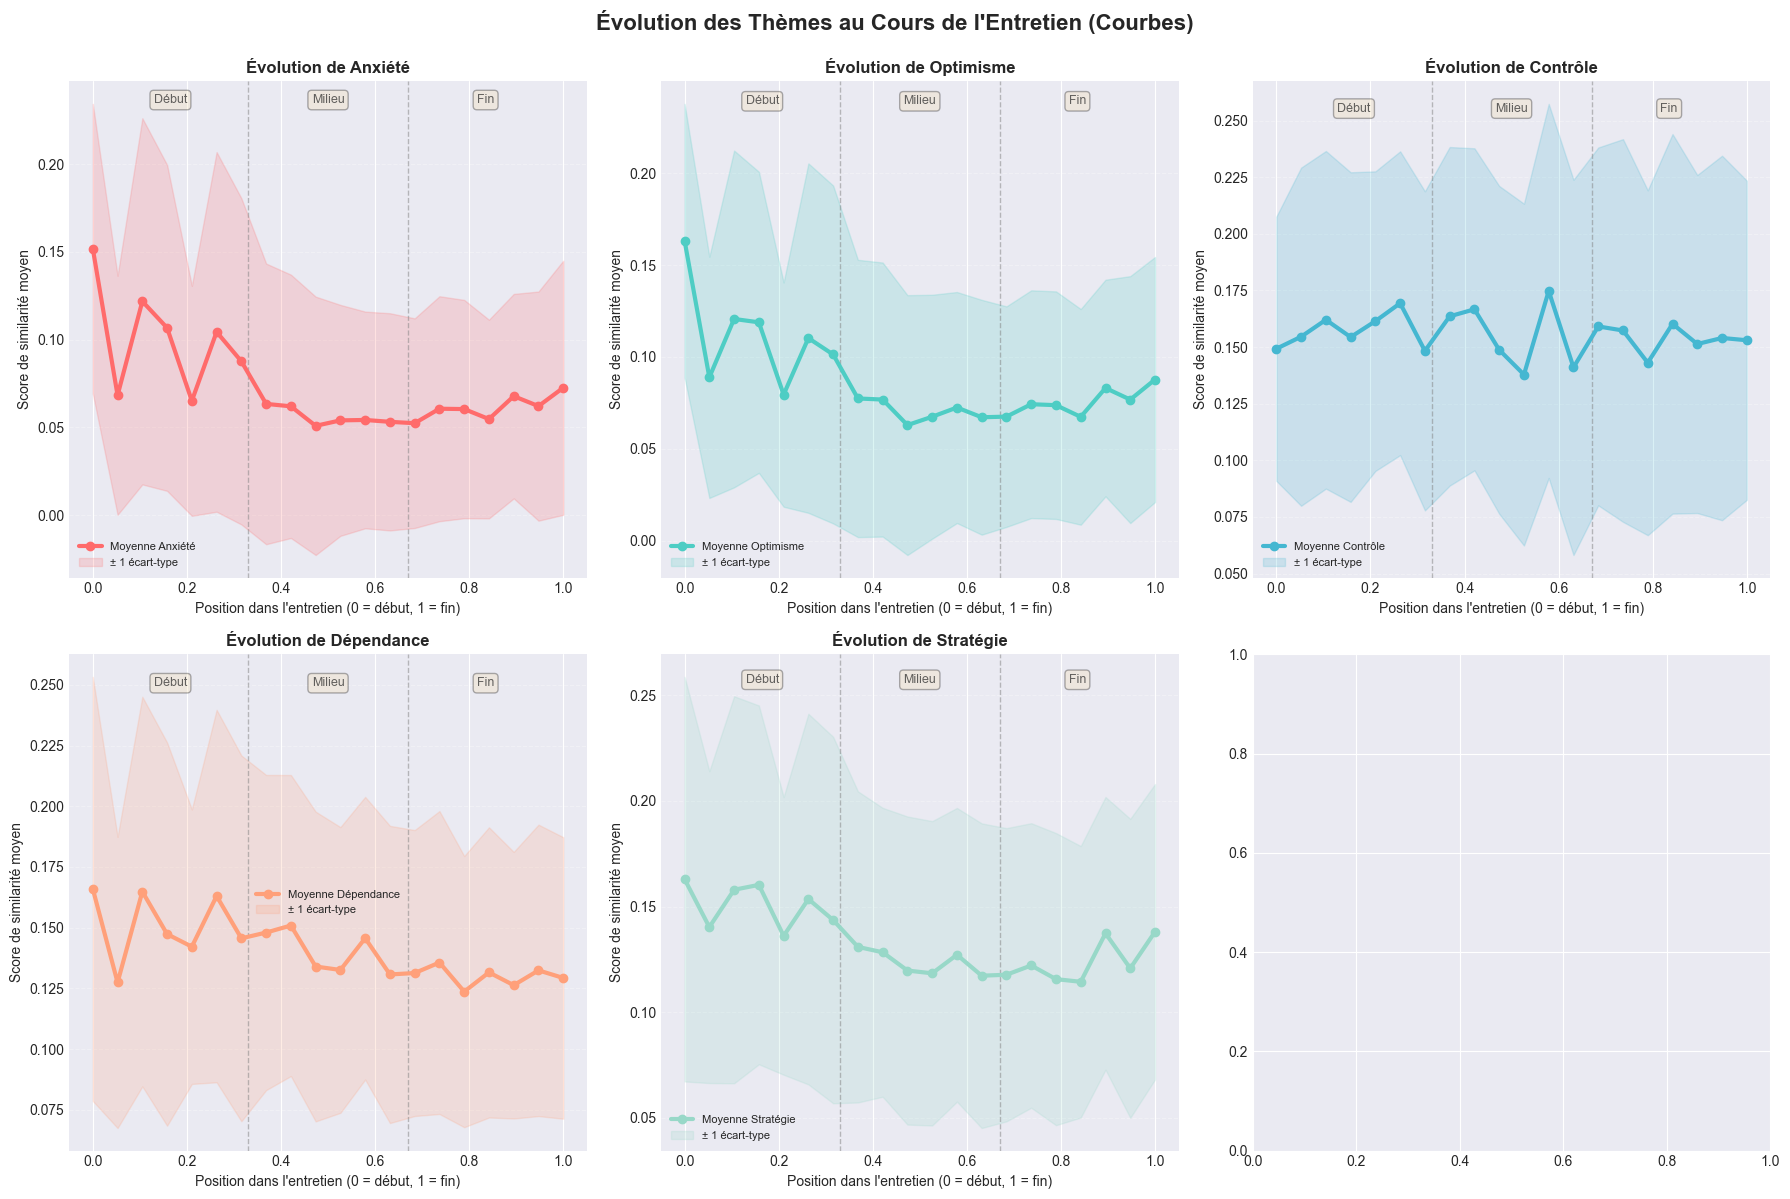


=== VUE D'ENSEMBLE : TOUTES LES COURBES ===


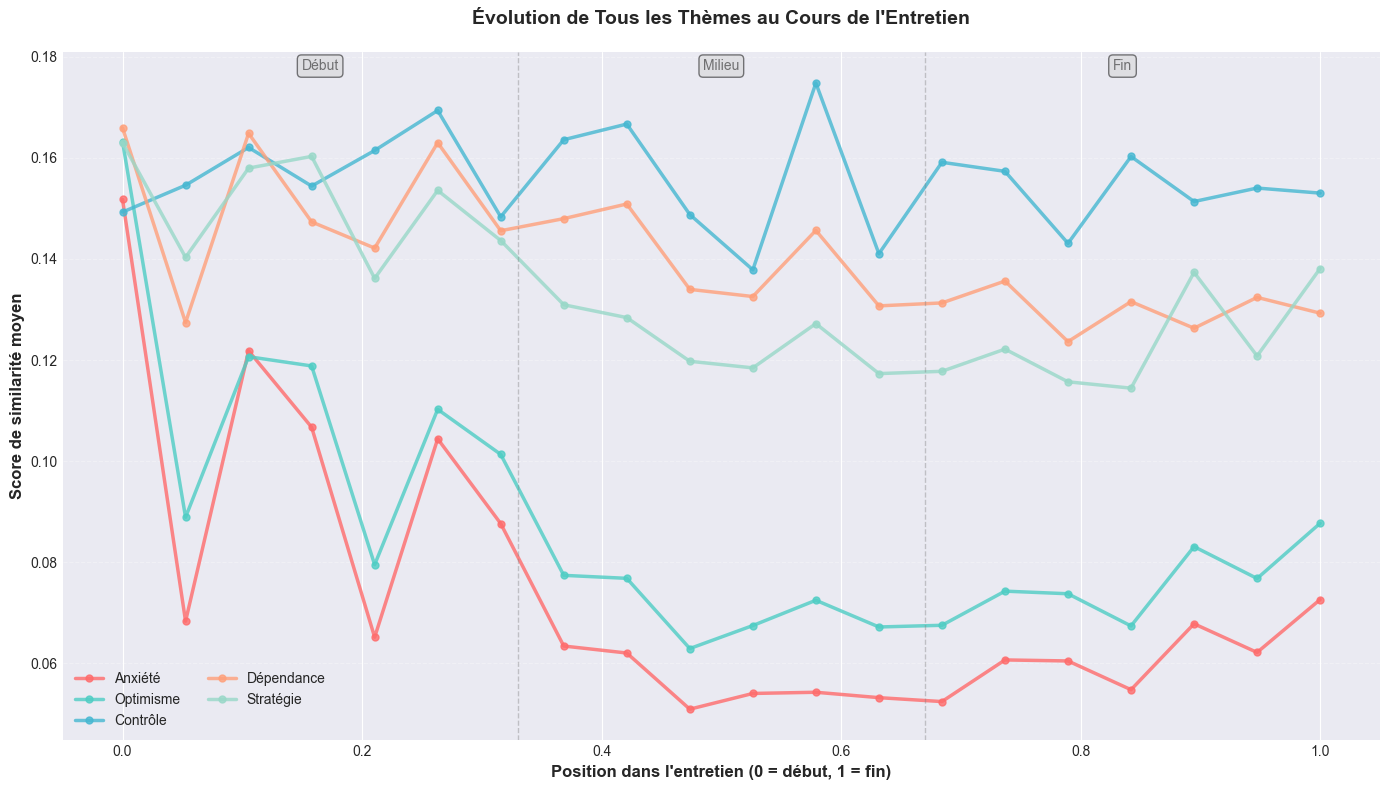

In [25]:
import  pandas as pd# Visualisation alternative : Courbes d'évolution (plus lisse et continue)
print("\n=== GÉNÉRATION DES COURBES D'ÉVOLUTION ===\n")

# Créer des bins pour la position relative (0.0 à 1.0) - 20 points pour une courbe lisse
df_evolution['position_bin'] = pd.cut(df_evolution['position_relative'], bins=20, labels=False) / 19.0

# Calculer les moyennes par position pour chaque thème
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

for idx, theme in enumerate(themes_evolution.keys()):
    ax = axes[idx]
    
    # Grouper par position_bin et calculer la moyenne et l'écart-type
    evolution_by_position = df_evolution.groupby('position_bin')[f'similarity_{theme}'].agg(['mean', 'std', 'count'])
    evolution_by_position = evolution_by_position.reset_index()
    
    # Positions pour la courbe (0.0 à 1.0)
    positions = evolution_by_position['position_bin'].values
    means = evolution_by_position['mean'].values
    stds = evolution_by_position['std'].values
    
    # Tracer la courbe principale
    ax.plot(positions, means, 
            color=colors[idx % len(colors)], 
            linewidth=3, 
            marker='o', 
            markersize=6,
            label=f'Moyenne {theme}',
            zorder=3)
    
    # Ajouter une zone d'incertitude (écart-type) pour montrer la variabilité
    ax.fill_between(positions, 
                     means - stds, 
                     means + stds, 
                     alpha=0.2, 
                     color=colors[idx % len(colors)],
                     label='± 1 écart-type',
                     zorder=1)
    
    # Marquer les transitions entre segments (début/milieu/fin)
    ax.axvline(x=0.33, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=0.67, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Ajouter des annotations pour les segments
    y_max = ax.get_ylim()[1]
    ax.text(0.165, y_max * 0.95, 'Début', ha='center', fontsize=9, alpha=0.7, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    ax.text(0.5, y_max * 0.95, 'Milieu', ha='center', fontsize=9, alpha=0.7,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    ax.text(0.835, y_max * 0.95, 'Fin', ha='center', fontsize=9, alpha=0.7,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    ax.set_title(f'Évolution de {theme}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Position dans l\'entretien (0 = début, 1 = fin)', fontsize=10)
    ax.set_ylabel('Score de similarité moyen', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)
    ax.legend(loc='best', fontsize=8)
    ax.set_xlim(-0.05, 1.05)

plt.suptitle('Évolution des Thèmes au Cours de l\'Entretien (Courbes)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Visualisation supplémentaire : Toutes les courbes sur un même graphique pour comparaison
print("\n=== VUE D'ENSEMBLE : TOUTES LES COURBES ===")
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

for idx, theme in enumerate(themes_evolution.keys()):
    evolution_by_position = df_evolution.groupby('position_bin')[f'similarity_{theme}'].agg(['mean', 'std'])
    evolution_by_position = evolution_by_position.reset_index()
    
    positions = evolution_by_position['position_bin'].values
    means = evolution_by_position['mean'].values
    
    # Courbe principale
    ax.plot(positions, means, 
            color=colors[idx % len(colors)], 
            linewidth=2.5, 
            marker='o', 
            markersize=5,
            label=theme,
            alpha=0.8)

# Marquer les transitions entre segments
ax.axvline(x=0.33, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(x=0.67, color='gray', linestyle='--', alpha=0.4, linewidth=1)
y_max = ax.get_ylim()[1]
ax.text(0.165, y_max * 0.98, 'Début', ha='center', fontsize=10, alpha=0.6,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
ax.text(0.5, y_max * 0.98, 'Milieu', ha='center', fontsize=10, alpha=0.6,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
ax.text(0.835, y_max * 0.98, 'Fin', ha='center', fontsize=10, alpha=0.6,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

ax.set_title('Évolution de Tous les Thèmes au Cours de l\'Entretien', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Position dans l\'entretien (0 = début, 1 = fin)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score de similarité moyen', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=10, framealpha=0.9, ncol=2)
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### 6.2 Identité professionnelle et tâches centrales

=== 6.2 IDENTITÉ PROFESSIONNELLE ET TÂCHES CENTRALES ===

=== INDICE DE FRAGILITÉ IDENTITAIRE PAR CLUSTER (POURCENTAGES) ===

Cluster 0 (1549 répliques):
  - Définition professionnelle: 0.19% (3 mentions)
  - Tâches refusées: 7.23% (112 mentions)
  - Menace identité: 0.19% (3 mentions)
  - Redéfinition: 0.06% (1 mentions)
  - Indice de fragilité (IFI): 0.0039

Cluster 1 (8617 répliques):
  - Définition professionnelle: 0.13% (11 mentions)
  - Tâches refusées: 7.45% (642 mentions)
  - Menace identité: 0.31% (27 mentions)
  - Redéfinition: 0.07% (6 mentions)
  - Indice de fragilité (IFI): 0.0067

Cluster 2 (1817 répliques):
  - Définition professionnelle: 0.00% (0 mentions)
  - Tâches refusées: 8.75% (159 mentions)
  - Menace identité: 0.11% (2 mentions)
  - Redéfinition: 0.06% (1 mentions)
  - Indice de fragilité (IFI): 0.0030


✓ DataFrame de fragilité créé avec 3 clusters


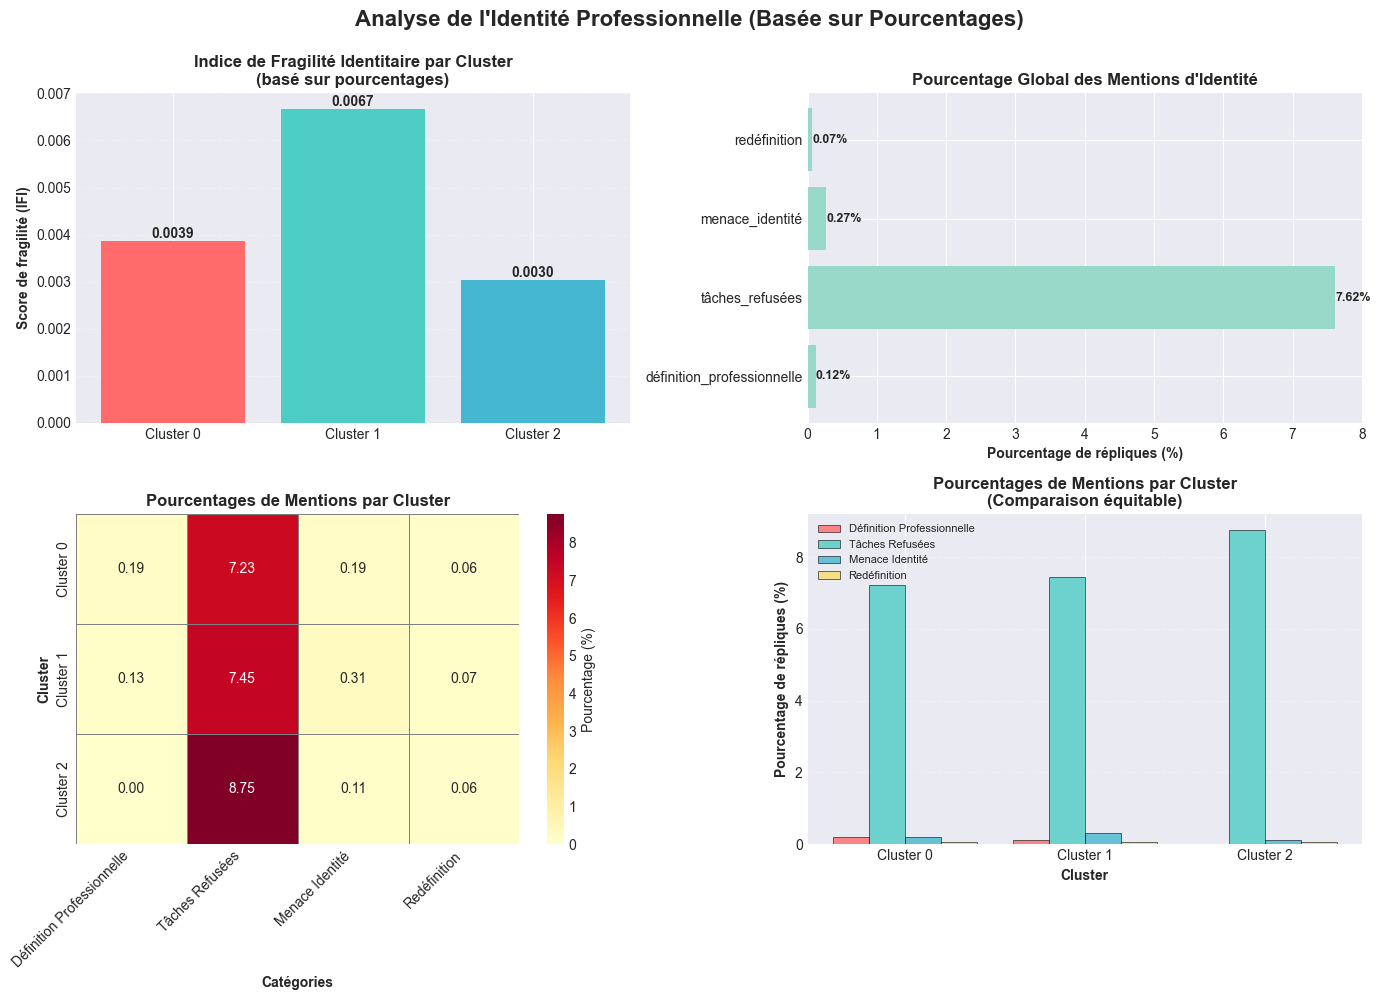


=== TABLEAU RÉCAPITULATIF (POURCENTAGES) ===
 cluster  total_repliques  pct_definition  pct_taches_refusees  pct_menace  pct_redefinition  fragilité
       0             1549        0.193673             7.230471    0.193673          0.064558   0.003873
       1             8617        0.127655             7.450389    0.313334          0.069630   0.006673
       2             1817        0.000000             8.750688    0.110072          0.055036   0.003027

=== CALCUL DE L'IFI PAR ENTRETIEN ===
✓ IFI calculé pour 1000 entretiens

Statistiques IFI par cluster:
  Cluster 0: moyenne=0.0192, médiane=0.0000, std=0.1544
  Cluster 1: moyenne=0.0394, médiane=0.0000, std=0.2445
  Cluster 2: moyenne=0.0248, médiane=0.0000, std=0.1910

✓ Analyse de l'identité professionnelle terminée (version avec pourcentages)


In [26]:
"""
Code pour remplacer l'analyse de fragilité identitaire (section 6.2)
Utilise des POURCENTAGES par cluster au lieu de nombres absolus
pour une comparaison équitable entre clusters de tailles différentes.
"""

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 6.2 IDENTITÉ PROFESSIONNELLE ET TÂCHES CENTRALES ===\n")

# Patterns pour identifier les mentions d'identité professionnelle
identity_patterns = {
    'définition_professionnelle': [
        r'\b(what makes me|what defines me|who I am as|my identity as|my role as)\b',
        r'\b(ce qui me définit|mon identité|qui je suis en tant que)\b',
        r'\b(core of my|heart of my|essence of my)\b',
        r'\b(cœur de mon|essence de mon|fondamental)\b'
    ],
    'tâches_refusées': [
        r'\b(won\'t let|refuse to|never let|don\'t want.*to do)\b',
        r'\b(je refuse|je ne laisse pas|jamais laisser)\b',
        r'\b(keep.*myself|do.*myself|handle.*myself)\b',
        r'\b(garder.*moi|faire.*moi|gérer.*moi)\b'
    ],
    'menace_identité': [
        r'\b(threaten|threat|endanger|risk.*identity)\b',
        r'\b(menace|risque.*identité|menacer)\b',
        r'\b(lose.*identity|losing.*who I am)\b',
        r'\b(perdre.*identité|perte.*identité)\b'
    ],
    'redéfinition': [
        r'\b(redefine|reinvent|transform.*role|evolve.*role)\b',
        r'\b(redéfinir|réinventer|transformer.*rôle)\b',
        r'\b(new role|different role|changing role)\b',
        r'\b(nouveau rôle|rôle différent|changement de rôle)\b'
    ]
}

# Fonction pour détecter les patterns
def detect_identity_mentions(text):
    if pd.isna(text) or not isinstance(text, str):
        return {}
    
    text_lower = text.lower()
    results = {}
    
    for category, patterns in identity_patterns.items():
        matches = []
        for pattern in patterns:
            if re.search(pattern, text_lower, re.IGNORECASE):
                matches.append(True)
        results[category] = len(matches) > 0
    
    return results

# Analyser toutes les répliques
identity_analysis = []
for idx, row in df_utterances.iterrows():
    utterance = row['utterance']
    mentions = detect_identity_mentions(utterance)
    
    identity_analysis.append({
        'parent_index': row.get('parent_index', idx),
        'cluster': row.get('cluster', None),
        'utterance': utterance,
        **mentions
    })

df_identity = pd.DataFrame(identity_analysis)

# Calculer un indice de fragilité identitaire par cluster (AVEC POURCENTAGES)
print("=== INDICE DE FRAGILITÉ IDENTITAIRE PAR CLUSTER (POURCENTAGES) ===\n")

# Stocker les résultats pour la visualisation
fragility_results = []

for cluster_id in sorted(df_identity['cluster'].dropna().unique()):
    cluster_data = df_identity[df_identity['cluster'] == cluster_id]
    total_repliques = len(cluster_data)
    
    # Calculer les POURCENTAGES au lieu des nombres absolus
    pct_definition = (cluster_data['définition_professionnelle'].sum() / total_repliques * 100) if total_repliques > 0 else 0
    pct_taches_refusees = (cluster_data['tâches_refusées'].sum() / total_repliques * 100) if total_repliques > 0 else 0
    pct_menace = (cluster_data['menace_identité'].sum() / total_repliques * 100) if total_repliques > 0 else 0
    pct_redefinition = (cluster_data['redéfinition'].sum() / total_repliques * 100) if total_repliques > 0 else 0
    
    # Calculer l'IFI basé sur les pourcentages (normalisé)
    fragilité = (
        pct_menace * 2 +           # Menace = +2
        pct_redefinition * 1.5 -   # Redéfinition = +1.5 (adaptation)
        pct_definition * 0.5       # Définition claire = -0.5 (protection)
    ) / 100.0  # Normaliser pour avoir un score entre -1 et +3 environ
    
    fragility_results.append({
        'cluster': int(cluster_id),
        'total_repliques': total_repliques,
        'pct_definition': pct_definition,
        'pct_taches_refusees': pct_taches_refusees,
        'pct_menace': pct_menace,
        'pct_redefinition': pct_redefinition,
        'fragilité': fragilité
    })
    
    print(f"Cluster {int(cluster_id)} ({total_repliques} répliques):")
    print(f"  - Définition professionnelle: {pct_definition:.2f}% ({cluster_data['définition_professionnelle'].sum()} mentions)")
    print(f"  - Tâches refusées: {pct_taches_refusees:.2f}% ({cluster_data['tâches_refusées'].sum()} mentions)")
    print(f"  - Menace identité: {pct_menace:.2f}% ({cluster_data['menace_identité'].sum()} mentions)")
    print(f"  - Redéfinition: {pct_redefinition:.2f}% ({cluster_data['redéfinition'].sum()} mentions)")
    print(f"  - Indice de fragilité (IFI): {fragilité:.4f}")
    print()

# Créer le DataFrame de fragilité
if len(fragility_results) > 0:
    df_fragility = pd.DataFrame(fragility_results)
    print(f"\n✓ DataFrame de fragilité créé avec {len(df_fragility)} clusters")
else:
    print("⚠ Aucun résultat de fragilité trouvé. Vérifiez que df_identity contient des données.")
    df_fragility = pd.DataFrame()

# Visualisation avec pourcentages
if len(df_fragility) > 0 and 'cluster' in df_fragility.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    categories = ['définition_professionnelle', 'tâches_refusées', 'menace_identité', 'redéfinition']

    # 1. Fragilité par cluster (basée sur pourcentages)
    ax1 = axes[0, 0]
    cluster_labels = [f'Cluster {int(c)}' for c in df_fragility['cluster']]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    bars = ax1.bar(cluster_labels, df_fragility['fragilité'], color=colors[:len(df_fragility)])

    # Ajouter les valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom' if height >= 0 else 'top', fontweight='bold', fontsize=10)

    ax1.set_title('Indice de Fragilité Identitaire par Cluster\n(basé sur pourcentages)', fontweight='bold')
    ax1.set_ylabel('Score de fragilité (IFI)', fontweight='bold')
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # 2. Pourcentages des mentions par catégorie (toutes catégories)
    ax2 = axes[0, 1]
    pct_data = []
    for cat in categories:
        # Calculer le pourcentage global (toutes répliques confondues)
        total = len(df_identity)
        count = df_identity[cat].sum()
        pct = (count / total * 100) if total > 0 else 0
        pct_data.append(pct)

    bars2 = ax2.barh(categories, pct_data, color='#98D8C8')
    for i, bar in enumerate(bars2):
        width = bar.get_width()
        ax2.text(width, bar.get_y() + bar.get_height()/2.,
                f'{width:.2f}%',
                ha='left', va='center', fontweight='bold', fontsize=9)

    ax2.set_title('Pourcentage Global des Mentions d\'Identité', fontweight='bold')
    ax2.set_xlabel('Pourcentage de répliques (%)', fontweight='bold')

    # 3. Comparaison des pourcentages par cluster (heatmap)
    ax3 = axes[1, 0]
    # Créer une matrice cluster x catégorie avec pourcentages
    heatmap_data = []
    for cluster_id in sorted(df_identity['cluster'].dropna().unique()):
        cluster_data = df_identity[df_identity['cluster'] == cluster_id]
        total = len(cluster_data)
        row = []
        for cat in categories:
            pct = (cluster_data[cat].sum() / total * 100) if total > 0 else 0
            row.append(pct)
        heatmap_data.append(row)

    heatmap_df = pd.DataFrame(heatmap_data, 
                              index=[f'Cluster {int(c)}' for c in sorted(df_identity['cluster'].dropna().unique())],
                              columns=[cat.replace('_', ' ').title() for cat in categories])

    sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax3, 
                cbar_kws={'label': 'Pourcentage (%)'}, linewidths=0.5, linecolor='gray')
    ax3.set_title('Pourcentages de Mentions par Cluster', fontweight='bold')
    ax3.set_xlabel('Catégories', fontweight='bold')
    ax3.set_ylabel('Cluster', fontweight='bold')
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

    # 4. Graphique en barres groupées : pourcentages par cluster
    ax4 = axes[1, 1]
    x = np.arange(len(df_fragility))
    width = 0.2
    colors_cat = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#F7DC6F']

    for i, cat in enumerate(categories):
        pct_values = []
        for cluster_id in sorted(df_identity['cluster'].dropna().unique()):
            cluster_data = df_identity[df_identity['cluster'] == cluster_id]
            total = len(cluster_data)
            pct = (cluster_data[cat].sum() / total * 100) if total > 0 else 0
            pct_values.append(pct)
        
        offset = (i - len(categories)/2 + 0.5) * width
        ax4.bar(x + offset, pct_values, width, label=cat.replace('_', ' ').title(), 
                color=colors_cat[i], alpha=0.8, edgecolor='black', linewidth=0.5)

    ax4.set_title('Pourcentages de Mentions par Cluster\n(Comparaison équitable)', fontweight='bold')
    ax4.set_xlabel('Cluster', fontweight='bold')
    ax4.set_ylabel('Pourcentage de répliques (%)', fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels([f'Cluster {int(c)}' for c in sorted(df_identity['cluster'].dropna().unique())])
    ax4.legend(loc='upper left', fontsize=8, framealpha=0.9)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')

    plt.suptitle('Analyse de l\'Identité Professionnelle (Basée sur Pourcentages)', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

    # Tableau récapitulatif
    print("\n=== TABLEAU RÉCAPITULATIF (POURCENTAGES) ===")
    print(df_fragility.to_string(index=False))
else:
    print("\n⚠ Impossible de créer les visualisations : df_fragility est vide")

# Calculer l'IFI par entretien pour le tableau final
print("\n=== CALCUL DE L'IFI PAR ENTRETIEN ===")
df_identity_per_interview = df_identity.groupby('parent_index').agg({
    'définition_professionnelle': 'sum',
    'tâches_refusées': 'sum',
    'menace_identité': 'sum',
    'redéfinition': 'sum',
    'cluster': 'first'
}).reset_index()

# Calculer l'IFI par entretien (basé sur les pourcentages de répliques dans l'entretien)
def calculate_ifi_per_interview(row):
    total = row['définition_professionnelle'] + row['tâches_refusées'] + row['menace_identité'] + row['redéfinition']
    if total == 0:
        return 0.0
    
    # Utiliser les pourcentages relatifs dans l'entretien
    pct_menace = (row['menace_identité'] / total * 100) if total > 0 else 0
    pct_redefinition = (row['redéfinition'] / total * 100) if total > 0 else 0
    pct_definition = (row['définition_professionnelle'] / total * 100) if total > 0 else 0
    
    ifi = (pct_menace * 2 + pct_redefinition * 1.5 - pct_definition * 0.5) / 100.0
    return ifi

df_identity_per_interview['ifi'] = df_identity_per_interview.apply(calculate_ifi_per_interview, axis=1)
df_identity_profiles = df_identity_per_interview[['parent_index', 'cluster', 'ifi']].copy()

print(f"✓ IFI calculé pour {len(df_identity_profiles)} entretiens")
print(f"\nStatistiques IFI par cluster:")
for cluster_id in sorted(df_identity_profiles['cluster'].dropna().unique()):
    cluster_ifi = df_identity_profiles[df_identity_profiles['cluster'] == cluster_id]['ifi']
    print(f"  Cluster {int(cluster_id)}: moyenne={cluster_ifi.mean():.4f}, médiane={cluster_ifi.median():.4f}, std={cluster_ifi.std():.4f}")

print("\n✓ Analyse de l'identité professionnelle terminée (version avec pourcentages)")


### 6.3 Stratégies d'adaptation à l'IA

### 6.4 Dissonance entre discours et pratiques

=== 6.4 DISSONANCE ENTRE DISCOURS ET PRATIQUES ===

=== INDICE DE DISSONANCE PAR CLUSTER ===

Cluster 0 (130 entretiens):
  - Discours normatif: 116 (89.2%)
  - Aveux implicites: 113 (86.9%)
  - Contradictions: 111 (85.4%)
  - Indice moyen de dissonance: 5.19

Cluster 1 (719 entretiens):
  - Discours normatif: 631 (87.8%)
  - Aveux implicites: 621 (86.4%)
  - Contradictions: 589 (81.9%)
  - Indice moyen de dissonance: 5.06

Cluster 2 (151 entretiens):
  - Discours normatif: 136 (90.1%)
  - Aveux implicites: 131 (86.8%)
  - Contradictions: 127 (84.1%)
  - Indice moyen de dissonance: 5.16



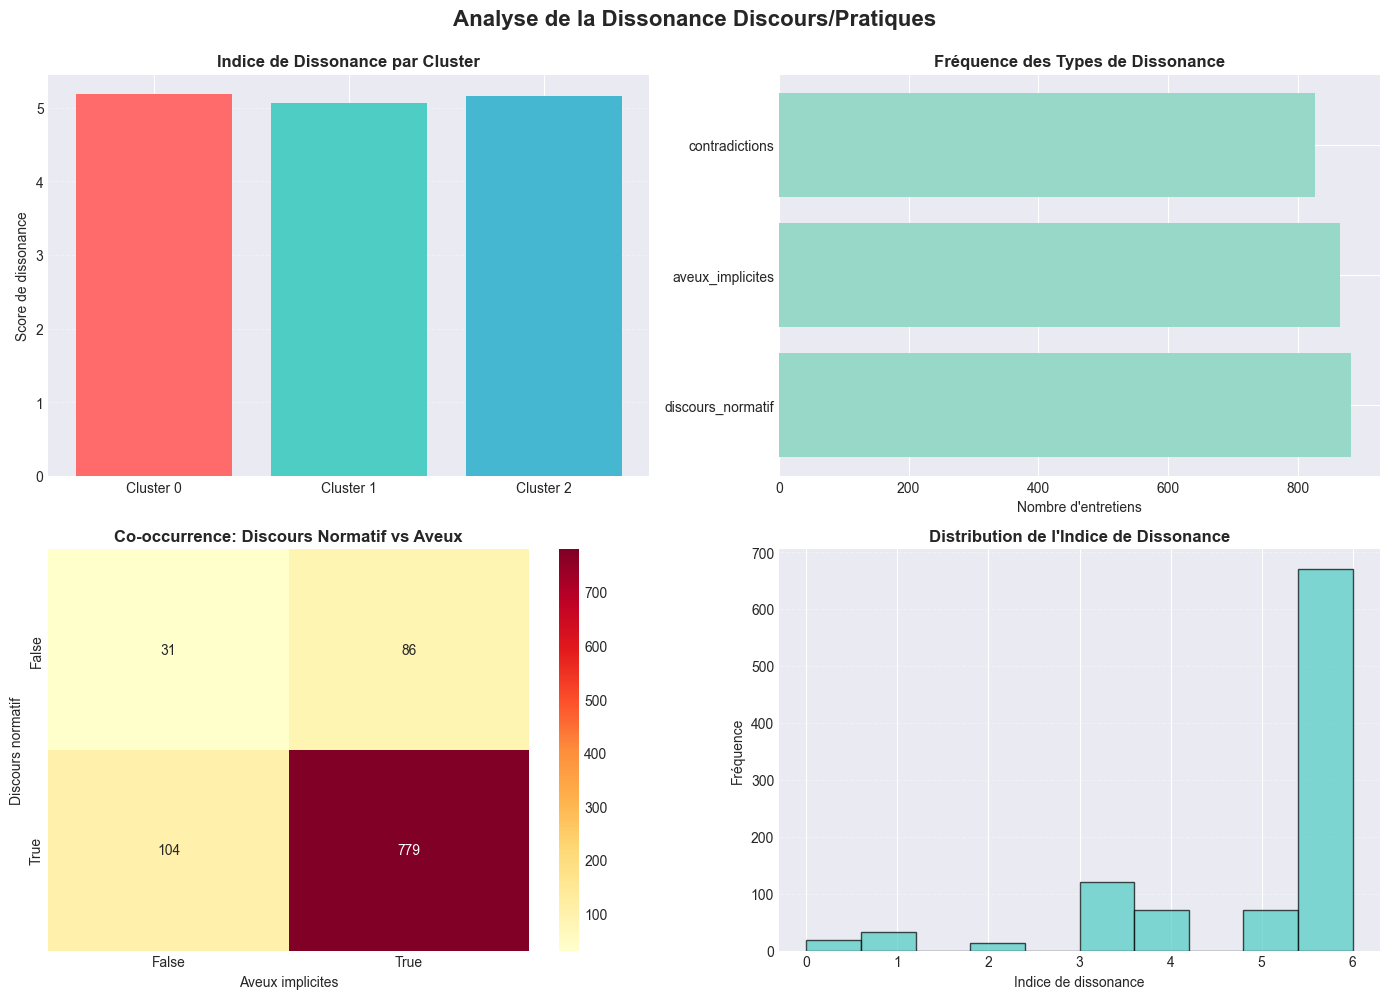

✓ Analyse de la dissonance terminée


In [29]:
print("=== 6.4 DISSONANCE ENTRE DISCOURS ET PRATIQUES ===\n")

# Patterns pour détecter le discours normatif vs les aveux
dissonance_patterns = {
    'discours_normatif': [
        r'\b(should|must|ought to|have to|need to|important to)\b',
        r'\b(je dois|il faut|important de|nécessaire de)\b',
        r'\b(keep.*control|maintain.*control|stay.*in.*charge)\b',
        r'\b(garder.*contrôle|maintenir.*contrôle|rester.*maître)\b',
        r'\b(I always|I never|I make sure|I ensure)\b'
    ],
    'aveux_implicites': [
        r'\b(actually|in practice|really|truth|admit|confess)\b',
        r'\b(en réalité|en pratique|vraiment|avouer|admettre)\b',
        r'\b(60%|70%|80%|90%|mostly|mainly|primarily)\b',
        r'\b(mostly.*ai|mainly.*ai|ai.*does|ai.*decides)\b',
        r'\b(ai.*drives|ai.*controls|ai.*leads)\b'
    ],
    'contradictions': [
        r'\b(but.*actually|however.*really|although.*in.*practice)\b',
        r'\b(mais.*en réalité|cependant.*vraiment|bien que.*pratique)\b',
        r'\b(say.*but|claim.*but|think.*but)\b'
    ]
}

def detect_dissonance(text):
    if pd.isna(text) or not isinstance(text, str):
        return {}
    
    text_lower = text.lower()
    results = {}
    
    for category, patterns in dissonance_patterns.items():
        matches = sum(1 for pattern in patterns if re.search(pattern, text_lower, re.IGNORECASE))
        results[category] = matches > 0
    
    return results

# Analyser par entretien (regrouper les répliques)
dissonance_by_transcript = {}
for idx, row in df_user_only.iterrows():
    transcript_id = row.get('transcript_id', f'row_{idx}')
    all_text = ' '.join([str(val) for col in df_user_only.columns 
                        if col.startswith('User_Turn_') and pd.notna(row.get(col, '')) 
                        for val in [row.get(col)]])
    
    dissonance = detect_dissonance(all_text)
    dissonance_by_transcript[transcript_id] = {
        'discours_normatif': dissonance.get('discours_normatif', False),
        'aveux_implicites': dissonance.get('aveux_implicites', False),
        'contradictions': dissonance.get('contradictions', False),
        'cluster': row.get('cluster', None)
    }

df_dissonance = pd.DataFrame.from_dict(dissonance_by_transcript, orient='index')
df_dissonance['indice_dissonance'] = (
    df_dissonance['discours_normatif'].astype(int) * 1 +
    df_dissonance['aveux_implicites'].astype(int) * 2 +
    df_dissonance['contradictions'].astype(int) * 3
)

print("=== INDICE DE DISSONANCE PAR CLUSTER ===\n")
for cluster_id in sorted(df_dissonance['cluster'].dropna().unique()):
    cluster_data = df_dissonance[df_dissonance['cluster'] == cluster_id]
    print(f"Cluster {int(cluster_id)} ({len(cluster_data)} entretiens):")
    print(f"  - Discours normatif: {cluster_data['discours_normatif'].sum()} ({cluster_data['discours_normatif'].mean()*100:.1f}%)")
    print(f"  - Aveux implicites: {cluster_data['aveux_implicites'].sum()} ({cluster_data['aveux_implicites'].mean()*100:.1f}%)")
    print(f"  - Contradictions: {cluster_data['contradictions'].sum()} ({cluster_data['contradictions'].mean()*100:.1f}%)")
    print(f"  - Indice moyen de dissonance: {cluster_data['indice_dissonance'].mean():.2f}")
    print()

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Indice de dissonance par cluster
ax1 = axes[0, 0]
dissonance_by_cluster = df_dissonance.groupby('cluster')['indice_dissonance'].mean()
ax1.bar([f'Cluster {int(c)}' for c in dissonance_by_cluster.index], 
        dissonance_by_cluster.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax1.set_title('Indice de Dissonance par Cluster', fontweight='bold')
ax1.set_ylabel('Score de dissonance')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# 2. Distribution des types de dissonance
ax2 = axes[0, 1]
dissonance_types = ['discours_normatif', 'aveux_implicites', 'contradictions']
counts = [df_dissonance[t].sum() for t in dissonance_types]
ax2.barh(dissonance_types, counts, color='#98D8C8')
ax2.set_title('Fréquence des Types de Dissonance', fontweight='bold')
ax2.set_xlabel('Nombre d\'entretiens')

# 3. Matrice de co-occurrence
ax3 = axes[1, 0]
cooccurrence = pd.crosstab(df_dissonance['discours_normatif'], df_dissonance['aveux_implicites'])
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', ax=ax3)
ax3.set_title('Co-occurrence: Discours Normatif vs Aveux', fontweight='bold')
ax3.set_xlabel('Aveux implicites')
ax3.set_ylabel('Discours normatif')

# 4. Distribution de l'indice de dissonance
ax4 = axes[1, 1]
ax4.hist(df_dissonance['indice_dissonance'], bins=10, color='#4ECDC4', edgecolor='black', alpha=0.7)
ax4.set_title('Distribution de l\'Indice de Dissonance', fontweight='bold')
ax4.set_xlabel('Indice de dissonance')
ax4.set_ylabel('Fréquence')
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Analyse de la Dissonance Discours/Pratiques', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Analyse de la dissonance terminée")

### 6.5 Stigmatisation sociale et usage caché

=== 6.5 STIGMATISATION SOCIALE ET USAGE CACHÉ ===

=== STIGMATISATION PAR CLUSTER ===

Cluster 0 (1549 répliques):
  - jugement_pairs: 21 (1.4%)
  - usage_caché: 8 (0.5%)
  - stress_émotionnel: 33 (2.1%)

Cluster 1 (8617 répliques):
  - jugement_pairs: 151 (1.8%)
  - usage_caché: 54 (0.6%)
  - stress_émotionnel: 153 (1.8%)

Cluster 2 (1817 répliques):
  - jugement_pairs: 17 (0.9%)
  - usage_caché: 6 (0.3%)
  - stress_émotionnel: 19 (1.0%)



C:\Users\Khyro\AppData\Local\Temp\ipykernel_25300\3837558951.py:99: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stigma_index = df_stigma.groupby('cluster').apply(


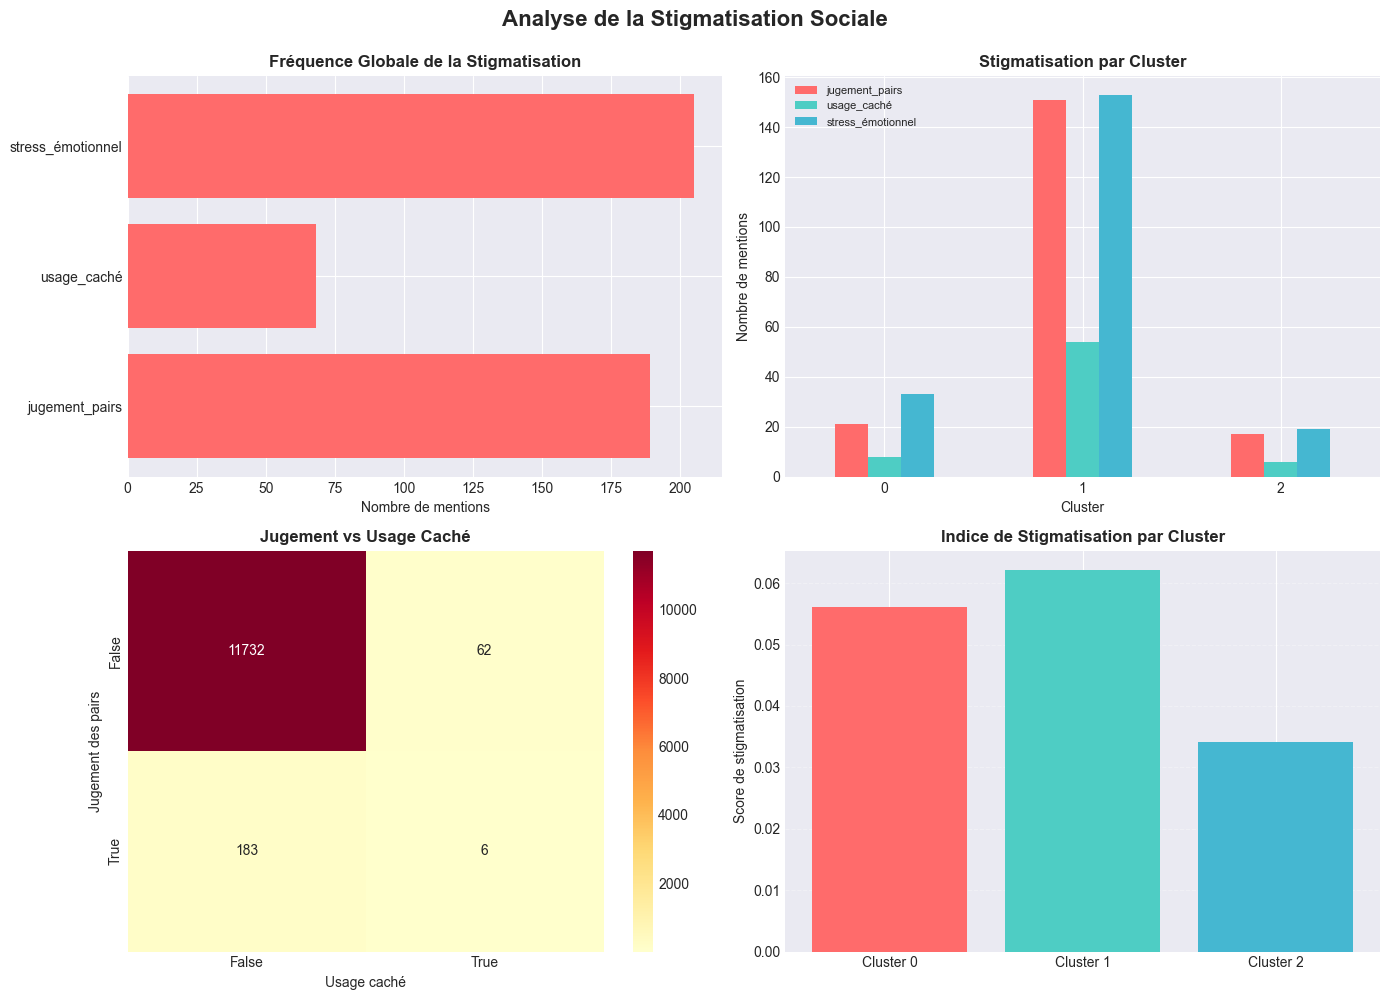

✓ Analyse de la stigmatisation sociale terminée


In [30]:
print("=== 6.5 STIGMATISATION SOCIALE ET USAGE CACHÉ ===\n")

# Patterns pour détecter la stigmatisation
stigma_patterns = {
    'jugement_pairs': [
        r'\b(judge|judgment|criticize|criticism|stigma|stigmatize)\b',
        r'\b(juger|jugement|critiquer|critique|stigmatiser|stigmatisation)\b',
        r'\b(peer.*judge|colleague.*think|people.*say|others.*think)\b',
        r'\b(collègues.*pensent|autres.*disent|gens.*pensent)\b'
    ],
    'usage_caché': [
        r'\b(hidden|secret|don\'t tell|keep.*quiet|don\'t mention|private)\b',
        r'\b(caché|secret|ne pas dire|garder.*secret|ne pas mentionner)\b',
        r'\b(use.*without.*telling|silent.*about|quiet.*about)\b',
        r'\b(utiliser.*sans.*dire|silencieux.*sur|discret.*sur)\b'
    ],
    'stress_émotionnel': [
        r'\b(anxious|worried|stress|pressure|uncomfortable|embarrassed)\b',
        r'\b(anxieux|inquiet|stress|pression|mal à l\'aise|gêné)\b',
        r'\b(feel.*bad|feel.*guilty|feel.*ashamed)\b',
        r'\b(se sentir.*mal|se sentir.*coupable|avoir.*honte)\b'
    ],
    'métier_visible': [
        r'\b(creative|artist|writer|designer|public|visible|show)\b',
        r'\b(créatif|artiste|écrivain|designer|public|visible|montrer)\b'
    ]
}

def detect_stigma(text):
    if pd.isna(text) or not isinstance(text, str):
        return {}
    
    text_lower = text.lower()
    results = {}
    
    for category, patterns in stigma_patterns.items():
        matches = sum(1 for pattern in patterns if re.search(pattern, text_lower, re.IGNORECASE))
        results[category] = matches > 0
    
    return results

# Analyser toutes les répliques
stigma_analysis = []
for idx, row in df_utterances.iterrows():
    utterance = row['utterance']
    stigma = detect_stigma(utterance)
    
    stigma_analysis.append({
        'parent_index': row.get('parent_index', idx),
        'cluster': row.get('cluster', None),
        'utterance': utterance,
        **stigma
    })

df_stigma = pd.DataFrame(stigma_analysis)

# Analyser par cluster
print("=== STIGMATISATION PAR CLUSTER ===\n")
for cluster_id in sorted(df_stigma['cluster'].dropna().unique()):
    cluster_data = df_stigma[df_stigma['cluster'] == cluster_id]
    print(f"Cluster {int(cluster_id)} ({len(cluster_data)} répliques):")
    for category in ['jugement_pairs', 'usage_caché', 'stress_émotionnel']:
        count = cluster_data[category].sum()
        pct = (count / len(cluster_data) * 100) if len(cluster_data) > 0 else 0
        print(f"  - {category}: {count} ({pct:.1f}%)")
    print()

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fréquence globale
ax1 = axes[0, 0]
stigma_categories = ['jugement_pairs', 'usage_caché', 'stress_émotionnel']
counts = [df_stigma[cat].sum() for cat in stigma_categories]
ax1.barh(stigma_categories, counts, color='#FF6B6B')
ax1.set_title('Fréquence Globale de la Stigmatisation', fontweight='bold')
ax1.set_xlabel('Nombre de mentions')

# 2. Stigmatisation par cluster
ax2 = axes[0, 1]
stigma_by_cluster = df_stigma.groupby('cluster')[stigma_categories].sum()
stigma_by_cluster.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax2.set_title('Stigmatisation par Cluster', fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Nombre de mentions')
ax2.legend(stigma_categories, loc='upper left', fontsize=8)
ax2.tick_params(axis='x', rotation=0)

# 3. Relation jugement vs usage caché
ax3 = axes[1, 0]
cooccurrence = pd.crosstab(df_stigma['jugement_pairs'], df_stigma['usage_caché'])
sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='YlOrRd', ax=ax3)
ax3.set_title('Jugement vs Usage Caché', fontweight='bold')
ax3.set_xlabel('Usage caché')
ax3.set_ylabel('Jugement des pairs')

# 4. Indice de stigmatisation par cluster
ax4 = axes[1, 1]
stigma_index = df_stigma.groupby('cluster').apply(
    lambda x: (x['jugement_pairs'].sum() * 2 + 
               x['usage_caché'].sum() * 1.5 + 
               x['stress_émotionnel'].sum() * 1) / len(x)
)
ax4.bar([f'Cluster {int(c)}' for c in stigma_index.index], 
        stigma_index.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax4.set_title('Indice de Stigmatisation par Cluster', fontweight='bold')
ax4.set_ylabel('Score de stigmatisation')
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Analyse de la Stigmatisation Sociale', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Analyse de la stigmatisation sociale terminée")

### 6.6 Inégalités et trajectoires professionnelles

=== 6.6 INÉGALITÉS ET TRAJECTOIRES PROFESSIONNELLES ===

=== INÉGALITÉS PAR CLUSTER ===

Cluster 0 (1549 répliques):
  - Avantages: 35 (2.3%)
  - Désavantages: 61 (3.9%)
  - Positionnement fort: 54 (3.5%)
  - Positionnement faible: 216 (13.9%)
  - Indice moyen d'inégalité: -0.14

Cluster 1 (8617 répliques):
  - Avantages: 261 (3.0%)
  - Désavantages: 220 (2.6%)
  - Positionnement fort: 313 (3.6%)
  - Positionnement faible: 947 (11.0%)
  - Indice moyen d'inégalité: -0.06

Cluster 2 (1817 répliques):
  - Avantages: 81 (4.5%)
  - Désavantages: 52 (2.9%)
  - Positionnement fort: 75 (4.1%)
  - Positionnement faible: 285 (15.7%)
  - Indice moyen d'inégalité: -0.08



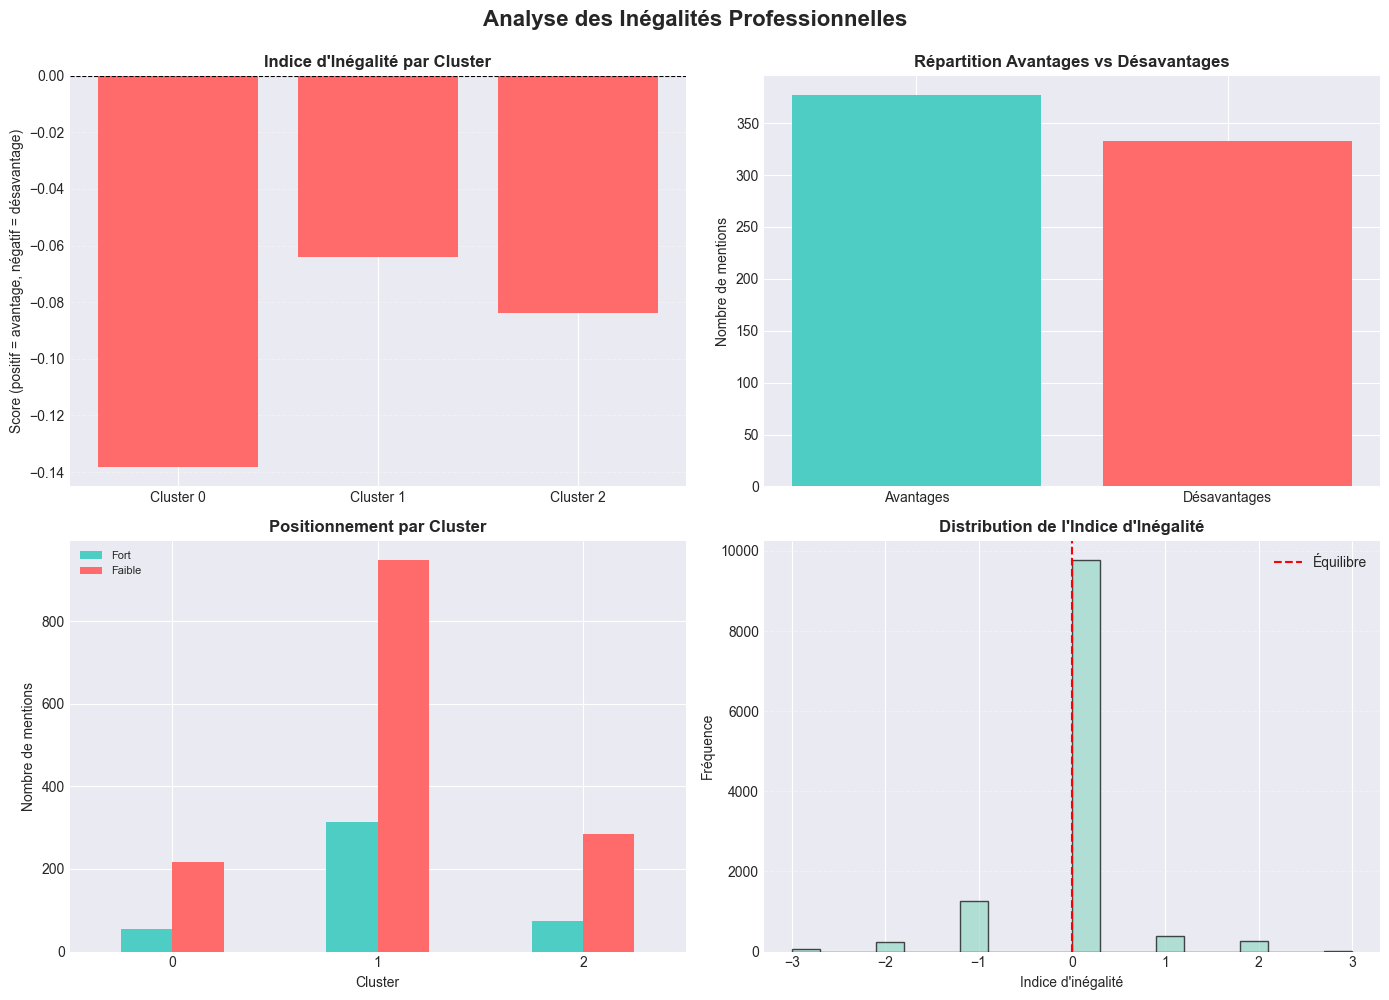

✓ Analyse des inégalités professionnelles terminée


In [31]:
print("=== 6.6 INÉGALITÉS ET TRAJECTOIRES PROFESSIONNELLES ===\n")

# Patterns pour identifier les avantages vs désavantages
inequality_patterns = {
    'avantage': [
        r'\b(2.*times|3.*times|twice|thrice|more.*productive|increase.*productivity)\b',
        r'\b(2.*fois|3.*fois|deux.*fois|trois.*fois|plus.*productif)\b',
        r'\b(competitive|stay.*ahead|advantage|edge|lead)\b',
        r'\b(compétitif|rester.*devant|avantage|marge|leader)\b',
        r'\b(produce.*more|output.*more|efficiency.*gain)\b'
    ],
    'désavantage': [
        r'\b(adapt.*survive|must.*adapt|struggle|difficult|challenging)\b',
        r'\b(s\'adapter.*survivre|dois.*m\'adapter|difficulté|défi)\b',
        r'\b(market.*saturated|saturated.*market|oversupply)\b',
        r'\b(marché.*saturé|saturation|surplus)\b',
        r'\b(fall.*behind|left.*behind|can\'t.*compete)\b',
        r'\b(être.*dépassé|ne.*peux.*pas.*rivaliser|perdre.*terrain)\b'
    ],
    'positionnement_fort': [
        r'\b(experience|experienced|expert|senior|established|well.*positioned)\b',
        r'\b(expérience|expérimenté|expert|senior|établi|bien.*positionné)\b',
        r'\b(years.*experience|long.*career|proven.*track)\b'
    ],
    'positionnement_faible': [
        r'\b(junior|new|recent|starting|entry.*level|beginner)\b',
        r'\b(junior|nouveau|récent|débutant|niveau.*entrée)\b',
        r'\b(just.*started|new.*to|learning|developing)\b'
    ]
}

def detect_inequality(text):
    if pd.isna(text) or not isinstance(text, str):
        return {}
    
    text_lower = text.lower()
    results = {}
    
    for category, patterns in inequality_patterns.items():
        matches = sum(1 for pattern in patterns if re.search(pattern, text_lower, re.IGNORECASE))
        results[category] = matches > 0
    
    return results

# Analyser toutes les répliques
inequality_analysis = []
for idx, row in df_utterances.iterrows():
    utterance = row['utterance']
    inequality = detect_inequality(utterance)
    
    inequality_analysis.append({
        'parent_index': row.get('parent_index', idx),
        'cluster': row.get('cluster', None),
        'utterance': utterance,
        **inequality
    })

df_inequality = pd.DataFrame(inequality_analysis)

# Calculer un indice d'inégalité (avantage - désavantage)
df_inequality['indice_inegalite'] = (
    df_inequality['avantage'].astype(int) * 2 -
    df_inequality['désavantage'].astype(int) * 2 +
    df_inequality['positionnement_fort'].astype(int) * 1 -
    df_inequality['positionnement_faible'].astype(int) * 1
)

print("=== INÉGALITÉS PAR CLUSTER ===\n")
for cluster_id in sorted(df_inequality['cluster'].dropna().unique()):
    cluster_data = df_inequality[df_inequality['cluster'] == cluster_id]
    print(f"Cluster {int(cluster_id)} ({len(cluster_data)} répliques):")
    print(f"  - Avantages: {cluster_data['avantage'].sum()} ({cluster_data['avantage'].mean()*100:.1f}%)")
    print(f"  - Désavantages: {cluster_data['désavantage'].sum()} ({cluster_data['désavantage'].mean()*100:.1f}%)")
    print(f"  - Positionnement fort: {cluster_data['positionnement_fort'].sum()} ({cluster_data['positionnement_fort'].mean()*100:.1f}%)")
    print(f"  - Positionnement faible: {cluster_data['positionnement_faible'].sum()} ({cluster_data['positionnement_faible'].mean()*100:.1f}%)")
    print(f"  - Indice moyen d'inégalité: {cluster_data['indice_inegalite'].mean():.2f}")
    print()

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Indice d'inégalité par cluster
ax1 = axes[0, 0]
inequality_by_cluster = df_inequality.groupby('cluster')['indice_inegalite'].mean()
colors = ['#FF6B6B' if v < 0 else '#4ECDC4' if v < 0.5 else '#45B7D1' 
          for v in inequality_by_cluster.values]
ax1.bar([f'Cluster {int(c)}' for c in inequality_by_cluster.index], 
        inequality_by_cluster.values, color=colors)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title('Indice d\'Inégalité par Cluster', fontweight='bold')
ax1.set_ylabel('Score (positif = avantage, négatif = désavantage)')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# 2. Avantages vs Désavantages
ax2 = axes[0, 1]
advantage_counts = [df_inequality['avantage'].sum(), df_inequality['désavantage'].sum()]
ax2.bar(['Avantages', 'Désavantages'], advantage_counts, color=['#4ECDC4', '#FF6B6B'])
ax2.set_title('Répartition Avantages vs Désavantages', fontweight='bold')
ax2.set_ylabel('Nombre de mentions')

# 3. Positionnement par cluster
ax3 = axes[1, 0]
positioning_by_cluster = df_inequality.groupby('cluster')[['positionnement_fort', 'positionnement_faible']].sum()
positioning_by_cluster.plot(kind='bar', ax=ax3, color=['#4ECDC4', '#FF6B6B'])
ax3.set_title('Positionnement par Cluster', fontweight='bold')
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Nombre de mentions')
ax3.legend(['Fort', 'Faible'], loc='upper left', fontsize=8)
ax3.tick_params(axis='x', rotation=0)

# 4. Distribution de l'indice d'inégalité
ax4 = axes[1, 1]
ax4.hist(df_inequality['indice_inegalite'], bins=20, color='#98D8C8', edgecolor='black', alpha=0.7)
ax4.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Équilibre')
ax4.set_title('Distribution de l\'Indice d\'Inégalité', fontweight='bold')
ax4.set_xlabel('Indice d\'inégalité')
ax4.set_ylabel('Fréquence')
ax4.legend()
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Analyse des Inégalités Professionnelles', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Analyse des inégalités professionnelles terminée")

## 7. Discussion et Synthèse

In [32]:
print("=== 7. DISCUSSION ET SYNTHÈSE ===\n")

# Synthèse des résultats par cluster
print("=== SYNTHÈSE DES RÉSULTATS PAR CLUSTER ===\n")

# Créer un tableau récapitulatif
summary_data = []

for cluster_id in sorted(df_user_only['cluster'].dropna().unique()):
    cluster_summary = {
        'Cluster': int(cluster_id),
        'Nb_entretiens': len(df_user_only[df_user_only['cluster'] == cluster_id]),
        'Nb_répliques': len(df_utterances[df_utterances['cluster'] == cluster_id]) if 'df_utterances' in globals() else 0
    }
    
    # Ajouter les indices calculés si disponibles
    if 'df_identity' in globals():
        cluster_identity = df_identity[df_identity['cluster'] == cluster_id]
        if len(cluster_identity) > 0:
            fragilité = (
                cluster_identity['menace_identité'].sum() * 2 +
                cluster_identity['redéfinition'].sum() * 1.5 -
                cluster_identity['définition_professionnelle'].sum() * 0.5
            ) / len(cluster_identity)
            cluster_summary['Fragilité_identité'] = f"{fragilité:.3f}"
    
    if 'df_dissonance' in globals():
        cluster_dissonance = df_dissonance[df_dissonance['cluster'] == cluster_id]
        if len(cluster_dissonance) > 0:
            cluster_summary['Dissonance'] = f"{cluster_dissonance['indice_dissonance'].mean():.2f}"
    
    if 'df_stigma' in globals():
        cluster_stigma = df_stigma[df_stigma['cluster'] == cluster_id]
        if len(cluster_stigma) > 0:
            stigma_idx = (
                cluster_stigma['jugement_pairs'].sum() * 2 +
                cluster_stigma['usage_caché'].sum() * 1.5 +
                cluster_stigma['stress_émotionnel'].sum() * 1
            ) / len(cluster_stigma)
            cluster_summary['Stigmatisation'] = f"{stigma_idx:.3f}"
    
    if 'df_inequality' in globals():
        cluster_inequality = df_inequality[df_inequality['cluster'] == cluster_id]
        if len(cluster_inequality) > 0:
            cluster_summary['Inégalité'] = f"{cluster_inequality['indice_inegalite'].mean():.2f}"
    
    summary_data.append(cluster_summary)

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print("\n=== INTERPRÉTATION GLOBALE ===\n")
print("Les analyses avancées révèlent des patterns complexes dans la transformation du travail par l'IA :")
print("1. Les clusters montrent des profils distincts en termes d'identité, dissonance, stigmatisation et inégalités")
print("2. La dissonance entre discours et pratiques suggère des tensions internes importantes")
print("3. La stigmatisation sociale influence l'adoption réelle de l'IA")
print("4. Les inégalités professionnelles sont accentuées par l'IA, favorisant certains profils")

print("\n=== IMPLICATIONS ===\n")
print("Théoriques :")
print("- L'IA transforme non seulement les tâches mais aussi l'identité professionnelle")
print("- Les normes sociales jouent un rôle crucial dans l'adoption technologique")
print("- Les inégalités existantes sont amplifiées par l'IA")
print("\nPratiques :")
print("- Nécessité de formations adaptées aux différents profils")
print("- Importance de la gestion de la stigmatisation en milieu professionnel")
print("- Besoin de politiques pour réduire les inégalités d'accès et d'usage")

print("\n✓ Discussion et synthèse terminées")

=== 7. DISCUSSION ET SYNTHÈSE ===

=== SYNTHÈSE DES RÉSULTATS PAR CLUSTER ===

 Cluster  Nb_entretiens  Nb_répliques Fragilité_identité Dissonance Stigmatisation Inégalité
       0            130          1549              0.004       5.19          0.056     -0.14
       1            719          8617              0.007       5.06          0.062     -0.06
       2            151          1817              0.003       5.16          0.034     -0.08

=== INTERPRÉTATION GLOBALE ===

Les analyses avancées révèlent des patterns complexes dans la transformation du travail par l'IA :
1. Les clusters montrent des profils distincts en termes d'identité, dissonance, stigmatisation et inégalités
2. La dissonance entre discours et pratiques suggère des tensions internes importantes
3. La stigmatisation sociale influence l'adoption réelle de l'IA
4. Les inégalités professionnelles sont accentuées par l'IA, favorisant certains profils

=== IMPLICATIONS ===

Théoriques :
- L'IA transforme non seulemen

## 8. Limites

In [ ]:
print("=== 8. LIMITES ET PERSPECTIVES ===\n")

print("=== LIMITES MÉTHODOLOGIQUES ===\n")
print("1. Biais de sélection :")
print("   - Échantillon recruté via plateformes de crowdworking")
print("   - Possible sur-représentation de profils favorables à l'IA")
print("   - Généralisation limitée à la population générale")

print("\n2. Auto-déclaration vs comportements réels :")
print("   - Décalage possible entre déclarations et pratiques réelles")
print("   - Biais de désirabilité sociale")
print("   - Nécessité de données d'usage réelles pour validation")

print("\n3. Snapshot temporel :")
print("   - Pas de suivi longitudinal des participants")
print("   - Évolution des attitudes non capturée")
print("   - Moment unique dans le processus d'adoption")

print("\n=== LIMITES ANALYTIQUES ===\n")
print("1. Interprétation des embeddings sémantiques :")
print("   - Modèles pré-entraînés peuvent avoir des biais")
print("   - Similarité cosine comme proxy de signification")
print("   - Validation qualitative nécessaire")

print("\n2. Classification des stratégies d'adaptation :")
print("   - Patterns regex peuvent manquer des nuances")
print("   - Catégorisation binaire (présent/absent)")
print("   - Codage manuel pour validation")

print("\n3. Détection de la dissonance cognitive :")
print("   - Complexité de capturer les contradictions implicites")
print("   - Nécessité d'analyse contextuelle approfondie")
print("   - Validation par analyse qualitative")

print("\n=== PERSPECTIVES FUTURES ===\n")
print("1. Améliorations méthodologiques :")
print("   - Suivi longitudinal des participants (6-12 mois)")
print("   - Comparaison avec données d'usage réelles (logs, métriques)")
print("   - Extension à d'autres groupes professionnels et cultures")

print("\n2. Analyses complémentaires :")
print("   - Analyse comparative inter-culturelle")
print("   - Modélisation prédictive des trajectoires professionnelles")
print("   - Étude des mécanismes de changement identitaire")
print("   - Analyse des réseaux sociaux et influence des pairs")

print("\n3. Approfondissements théoriques :")
print("   - Modélisation de la dynamique identité-profession")
print("   - Théorie de la dissonance cognitive appliquée à l'IA")
print("   - Sociologie des inégalités technologiques")

print("\n✓ Limites et perspectives documentées")

=== 8. LIMITES ET PERSPECTIVES ===

=== LIMITES MÉTHODOLOGIQUES ===

1. Biais de sélection :
   - Échantillon recruté via plateformes de crowdworking
   - Possible sur-représentation de profils favorables à l'IA
   - Généralisation limitée à la population générale

2. Auto-déclaration vs comportements réels :
   - Décalage possible entre déclarations et pratiques réelles
   - Biais de désirabilité sociale
   - Nécessité de données d'usage réelles pour validation

3. Snapshot temporel :
   - Pas de suivi longitudinal des participants
   - Évolution des attitudes non capturée
   - Moment unique dans le processus d'adoption

=== LIMITES ANALYTIQUES ===

1. Interprétation des embeddings sémantiques :
   - Modèles pré-entraînés peuvent avoir des biais
   - Similarité cosine comme proxy de signification
   - Validation qualitative nécessaire

2. Classification des stratégies d'adaptation :
   - Patterns regex peuvent manquer des nuances
   - Catégorisation binaire (présent/absent)
   - Codag